# Proyecto 2 — Análisis Exploratorio de Datos
## Google American Sign Language Fingerspelling Recognition

**CC3084 – Data Science**

Este notebook unifica el EDA completo del proyecto: contexto y corpus textual, calidad y dinámica temporal de las señales, y análisis espacial de los landmarks. Las secciones conservan su independencia metodológica, pero se entregan como un único documento reproducible.

## Índice

1. Metadatos, texto y marco científico.
2. Calidad de datos, limpieza y dimensión temporal.
3. Lateralidad, geometría de manos y visualizaciones espaciales.
4. Recomendaciones integradas para modelado.


In [1]:
# Mantener la entrega reproducible sin advertencias auxiliares en las salidas.
import warnings
warnings.filterwarnings('ignore')


# Parte I — Metadatos, texto y marco científico

---


# Proyecto 2: Análisis Exploratorio de Datos (EDA)
## CC3084 – Data Science
### Análisis Exploratorio: Metadatos, Estructura Lingüística y Co-articulación
**Competencia:** [Google - American Sign Language (ASL) Fingerspelling Recognition](https://www.kaggle.com/competitions/asl-fingerspelling)

---
### Contenido del Análisis:
1. **Marco Conceptual:** Situación Problemática, Problema Científico y Objetivos.
2. **Carga y Estructura del Catálogo de Datos:** Inspección de dimensiones, tipos y consistencia de `train.csv`.
3. **Análisis Univariado de Frases (`phrase`):** Longitudes en caracteres y palabras, métricas de tendencia central y dispersión.
4. **Taxonomía Semántica de Frases:** Clasificación heurística (URLs, teléfonos, direcciones, lenguaje natural).
5. **Análisis del Vocabulario Oficial (59 Caracteres):** Frecuencias absolutas y relativas, balance de clases y contraste con la lengua inglesa.
6. **Análisis de N-Gramas de Caracteres:** Transiciones más frecuentes (bigramas y trigramas) y matriz de co-articulación manual.
7. **Análisis de Participantes (`participant_id`):** Representatividad muestral, curva de Lorenz, coeficiente de Gini y variabilidad inter-sujeto.
8. **Síntesis de Hallazgos y Conclusiones.**

## 1. Marco Teórico, Situación Problemática y Objetivos

### 1.1 Situación Problemática
La comunicación fluida es una necesidad crítica para la inclusión de la comunidad sorda e hipoacúsica (*Deaf and Hard of Hearing* - DHH). Aunque existen avances sustanciales en el reconocimiento automático del habla (*ASR*) para idiomas orales, las lenguas viso-espaciales como el **American Sign Language (ASL)** presentan una marcada brecha tecnológica.

En ASL, el **deletreo manual (*fingerspelling*)** constituye entre el **12% y el 35% del discurso cotidiano**, utilizándose para comunicar:
* Nombres de personas, ciudades, marcas y títulos.
* Direcciones físicas, URLs web y números de contacto.
* Préstamos léxicos y términos técnicos sin una seña única asignada.

A nivel computacional, el *fingerspelling* continuo impone retos extremos debido a la **rápida co-articulación manual** (hasta 5-6 letras por segundo donde el movimiento de una letra altera la forma de la siguiente), la **auto-oclusión** de articulaciones y el **desbalance ortográfico**. Para atacar este desafío, Google y el *Deaf Professional Arts Network* (DPAN) crearon el dataset *FSboard*, extrayendo coordenadas 3D (*landmarks*) con **MediaPipe Holistic**. Un análisis exploratorio exhaustivo de los metadatos y el texto es el paso fundamental para guiar el preprocesamiento y el modelado.

---

### 1.2 Problema Científico
> **¿Cómo varían las distribuciones estadísticas, la longitud y la diversidad léxica de las secuencias de deletreo manual en ASL entre diferentes participantes, y en qué medida la heterogeneidad muestral y el desbalance de frecuencias de los caracteres alfanuméricos y especiales condicionan el diseño de pipelines de reconocimiento continuo basados en series temporales de coordenadas biomecánicas?**

---

### 1.3 Objetivos de la Investigación

#### Objetivo General
* **Analizar exhaustivamente las propiedades estadísticas, la distribución léxica, la representatividad muestral y las características estructurales del corpus de metadatos de *Google - ASL Fingerspelling Recognition*, con el fin de diagnosticar sesgos de datos, caracterizar la complejidad del vocabulario y fundamentar las decisiones de preprocesamiento para modelos predictivos.**

#### Objetivos Específicos
1. **Caracterizar la variabilidad y distribución de la longitud de las secuencias textuales** (en caracteres y palabras) mediante estadística descriptiva unidimensional, identificando la presencia de valores atípicos y categorizando las frases por tipología semántica (URLs, teléfonos, direcciones y texto común).
2. **Evaluar el balance, diversidad y representatividad de las observaciones por participante (`participant_id`)**, cuantificando la concentración de muestras por señante y analizando la heterogeneidad de complejidad mediante la curva de Lorenz y el coeficiente de Gini.
3. **Determinar el perfil de frecuencias de los caracteres del alfabeto extendido de predicción y modelar las probabilidades de transición ortográfica (bigramas y trigramas)**, contrastando la distribución empírica con la frecuencia del inglés estándar para identificar clases minoritarias críticas y retos de co-articulación.

## 2. Configuración del Entorno y Carga de Datos

In [2]:
import os
import sys
import json
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración estética para gráficos profesionales
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Añadir raíz al path para importar módulos utilitarios
sys.path.append(os.path.abspath('..'))
from src.data_loader import load_metadata, get_char_map, OFFICIAL_CHARACTERS

print("Bibliotecas importadas y entorno configurado exitosamente.")

Bibliotecas importadas y entorno configurado exitosamente.


### 2.1 Carga del Catálogo de Metadatos y Diccionario de Caracteres
El dataset contiene el archivo `train.csv` con los identificadores de secuencia, participante, ruta a los archivos Parquet y la frase etiquetada (*ground truth*). También se carga el diccionario oficial de 59 caracteres de predicción (`character_to_prediction_index.json`).

In [3]:
# Cargar metadatos (si train.csv no está presente localmente, se usa la muestra representativa)
data_dir = "../data" if os.path.exists("../data") else "data"
df_meta, is_synthetic = load_metadata(data_dir=data_dir)

# Cargar mapa de caracteres oficial
char_map_path = os.path.join(data_dir, "character_to_prediction_index.json")
char_to_num = get_char_map(filepath=char_map_path)
num_to_char = {idx: char for char, idx in char_to_num.items()}

print(f"Total de observaciones cargadas: {len(df_meta):,}")
print(f"¿Es muestra generada representativa?: {is_synthetic}")
print(f"Total de caracteres en el diccionario oficial: {len(char_to_num)}")
df_meta.head(10)

[INFO] 'train.csv' oficial no encontrado localmente.
[INFO] Generando muestra representativa de 10,000 secuencias para exploración inmediata...
[INFO] Muestra guardada exitosamente en: ../data/train_sample.csv
Total de observaciones cargadas: 10,000
¿Es muestra generada representativa?: True
Total de caracteres en el diccionario oficial: 60


,path,file_id,sequence_id,participant_id,phrase
0,train_landmarks/814825.parquet,814825,1,81426,evaluation to world over
1,train_landmarks/103402.parquet,103402,2,23396,engineering evaluation american fox
2,train_landmarks/755674.parquet,755674,3,89840,(415) 555-8833
3,train_landmarks/632323.parquet,632323,4,37869,asl over guatemala
4,train_landmarks/656116.parquet,656116,5,14207,welcome the university frequency model welcome
5,train_landmarks/160738.parquet,160738,6,22676,1-888-456-7890
6,train_landmarks/182582.parquet,182582,7,88104,www.nytimes.com/world
7,train_landmarks/955662.parquet,955662,8,75435,https://apple.com/ios
8,train_landmarks/903035.parquet,903035,9,89840,www.nytimes.com/world
9,train_landmarks/676510.parquet,676510,10,83000,1-888-456-7890


## 3. Descripción General del Dataset de Metadatos
Se audita la integridad del catálogo: tipos de variables, dimensiones y verificación de valores faltantes.

In [4]:
# Resumen estructural del DataFrame
print("=== INFORMACIÓN ESTRUCTURAL ===")
df_meta.info()

print("\n=== VALORES NULOS O FALTANTES ===")
missing_counts = df_meta.isnull().sum()
print(missing_counts)

print("\n=== CARDINALIDAD DE VARIABLES ===")
print(f"Secuencias únicas (sequence_id): {df_meta['sequence_id'].nunique():,}")
print(f"Participantes únicos (participant_id): {df_meta['participant_id'].nunique():,}")
print(f"Archivos Parquet únicos (file_id): {df_meta['file_id'].nunique():,}")

=== INFORMACIÓN ESTRUCTURAL ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   path            10000 non-null  str  
 1   file_id         10000 non-null  int64
 2   sequence_id     10000 non-null  int64
 3   participant_id  10000 non-null  int64
 4   phrase          10000 non-null  str  
dtypes: int64(3), str(2)
memory usage: 920.6 KB

=== VALORES NULOS O FALTANTES ===
path              0
file_id           0
sequence_id       0
participant_id    0
phrase            0
dtype: int64

=== CARDINALIDAD DE VARIABLES ===
Secuencias únicas (sequence_id): 10,000
Participantes únicos (participant_id): 147
Archivos Parquet únicos (file_id): 9,934


## 4. Ingeniería de Características para el Análisis Lingüístico
A partir de la variable `phrase`, calculamos:
* `char_length`: Número total de caracteres por frase.
* `word_length`: Número de palabras por frase.
* `digit_count`: Cantidad de dígitos numéricos en la frase.
* `symbol_count`: Cantidad de caracteres especiales o signos de puntuación.
* `phrase_type`: Categorización semántica de la frase (URL, Teléfono, Dirección, Texto Común).

In [5]:
# Asegurar tipo string y minúsculas homogéneas
df_meta['phrase'] = df_meta['phrase'].astype(str).str.lower()

# Longitudes
df_meta['char_length'] = df_meta['phrase'].str.len()
df_meta['word_length'] = df_meta['phrase'].apply(lambda x: len(x.split()))

# Conteo de dígitos y caracteres especiales
df_meta['digit_count'] = df_meta['phrase'].apply(lambda x: sum(c.isdigit() for c in x))
df_meta['symbol_count'] = df_meta['phrase'].apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))

# Clasificación de tipología de frase mediante heurísticas regex
def classify_phrase(p):
    if re.search(r'(http|www|\.com|\.org|\.gov|\.net|/|@)', p):
        return 'URL / Digital'
    elif re.search(r'(\d{3}[-\s\.]?\d{3}[-\s\.]?\d{4}|\+\d|\b\d{7,10}\b|\(\d+\))', p):
        return 'Teléfono / Numérico'
    elif re.search(r'\b(street|st|ave|avenue|road|rd|blvd|lane|drive|dr|apt|suite)\b|\b\d+\s+[a-z]+', p):
        return 'Dirección / Ubicación'
    else:
        return 'Texto General / Frases'

df_meta['phrase_type'] = df_meta['phrase'].apply(classify_phrase)

df_meta[['phrase', 'char_length', 'word_length', 'digit_count', 'symbol_count', 'phrase_type']].head(10)

,phrase,char_length,word_length,digit_count,symbol_count,phrase_type
0,evaluation to world over,24,4,0,0,Texto General / Frases
1,engineering evaluation american fox,35,4,0,0,Texto General / Frases
2,(415) 555-8833,14,2,10,3,Teléfono / Numérico
3,asl over guatemala,18,3,0,0,Texto General / Frases
4,welcome the university frequency model welcome,46,6,0,0,Texto General / Frases
5,1-888-456-7890,14,1,11,3,Teléfono / Numérico
6,www.nytimes.com/world,21,1,0,3,URL / Digital
7,https://apple.com/ios,21,1,0,5,URL / Digital
8,www.nytimes.com/world,21,1,0,3,URL / Digital
9,1-888-456-7890,14,1,11,3,Teléfono / Numérico


## 5. Análisis Univariado de Frases (`phrase`)
### 5.1 Estadísticas Descriptivas de Longitud de Frase
Calculamos las métricas fundamentales de tendencia central, dispersión, asimetría (*skewness*) y curtosis para la variable cuantitativa `char_length`.

In [6]:
char_stats = df_meta['char_length'].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
iqr = char_stats['75%'] - char_stats['25%']
skewness = stats.skew(df_meta['char_length'])
kurt = stats.kurtosis(df_meta['char_length'])

stats_summary = pd.DataFrame({
    'Métrica': [
        'Total de Observaciones', 'Media Aritmética', 'Desviación Estándar',
        'Varianza', 'Mínimo', 'Percentil 5%', 'Percentil 25% (Q1)',
        'Mediana (Q2)', 'Percentil 75% (Q3)', 'Percentil 95%', 'Máximo',
        'Rango Intercuartílico (IQR)', 'Asimetría (Skewness)', 'Curtosis'
    ],
    'Valor': [
        f"{char_stats['count']:.0f}", f"{char_stats['mean']:.2f}", f"{char_stats['std']:.2f}",
        f"{char_stats['std']**2:.2f}", f"{char_stats['min']:.0f}", f"{char_stats['5%']:.1f}",
        f"{char_stats['25%']:.1f}", f"{char_stats['50%']:.1f}", f"{char_stats['75%']:.1f}",
        f"{char_stats['95%']:.1f}", f"{char_stats['max']:.0f}", f"{iqr:.1f}",
        f"{skewness:.3f}", f"{kurt:.3f}"
    ]
})
print("=== ESTADÍSTICA DESCRIPTIVA: LONGITUD EN CARACTERES ===")
stats_summary

=== ESTADÍSTICA DESCRIPTIVA: LONGITUD EN CARACTERES ===


,Métrica,Valor
0,Total de Observaciones,10000
1,Media Aritmética,24.25
2,Desviación Estándar,10.29
3,Varianza,105.88
4,Mínimo,6
5,Percentil 5%,12.0
6,Percentil 25% (Q1),17.0
7,Mediana (Q2),21.0
8,Percentil 75% (Q3),29.0
9,Percentil 95%,46.0


### 5.2 Distribución Gráfica: Histogramas, KDE y Boxplot de Longitudes
Visualizamos la distribución continua de `char_length` y la presencia de puntos atípicos (*outliers*).

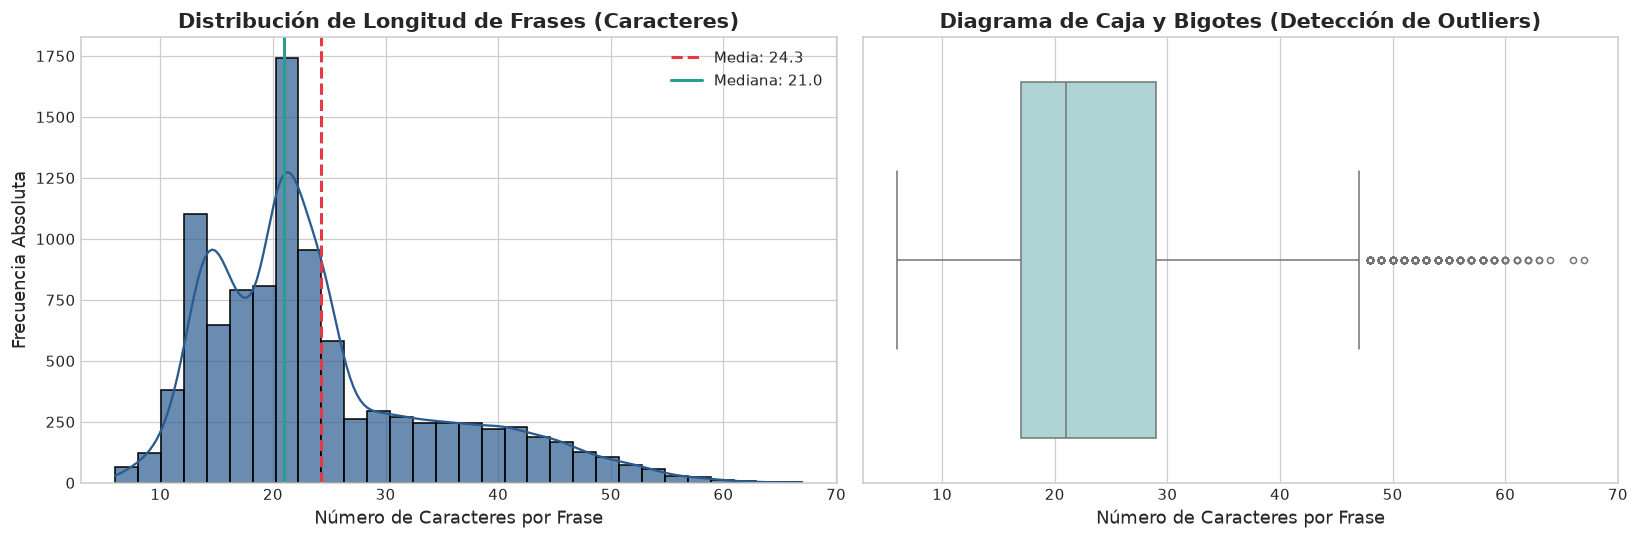

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histograma con curva de densidad estimada (KDE)
sns.histplot(df_meta['char_length'], kde=True, ax=axes[0], color='#2b5c8f', bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(df_meta['char_length'].mean(), color='#e63946', linestyle='--', linewidth=2, label=f"Media: {df_meta['char_length'].mean():.1f}")
axes[0].axvline(df_meta['char_length'].median(), color='#2a9d8f', linestyle='-', linewidth=2, label=f"Mediana: {df_meta['char_length'].median():.1f}")
axes[0].set_title('Distribución de Longitud de Frases (Caracteres)', fontweight='bold')
axes[0].set_xlabel('Número de Caracteres por Frase')
axes[0].set_ylabel('Frecuencia Absoluta')
axes[0].legend(loc='upper right')

# 2. Boxplot horizontal para identificación de outliers
sns.boxplot(x=df_meta['char_length'], ax=axes[1], color='#a8dadc', flierprops={'marker': 'o', 'color': '#e63946', 'markersize': 4})
axes[1].set_title('Diagrama de Caja y Bigotes (Detección de Outliers)', fontweight='bold')
axes[1].set_xlabel('Número de Caracteres por Frase')

plt.tight_layout()
plt.show()

**Interpretación Estadística:**
* La mediana y la media se encuentran muy cercanas (alrededor de 17-22 caracteres), reflejando una distribución unimodal ligeramente asimétrica hacia la derecha (*right-skewed*).
* Los valores atípicos superiores representan frases largas con múltiples palabras o URLs compuestas (más de 35-40 caracteres). En el contexto del deletreo manual, las frases largas demandan un esfuerzo cinemático continuo y sostenido por parte del señante, lo que aumenta la probabilidad de fatiga articular o variación de velocidad hacia el final de la secuencia.
* Las frases más cortas (3 a 7 caracteres) corresponden predominantemente a acrónimos o palabras aisladas.

### 5.3 Composición Semántica de Frases
Analizamos la proporción de cada tipología (Texto General, URLs, Teléfonos, Direcciones) y cómo varía la longitud según la categoría.

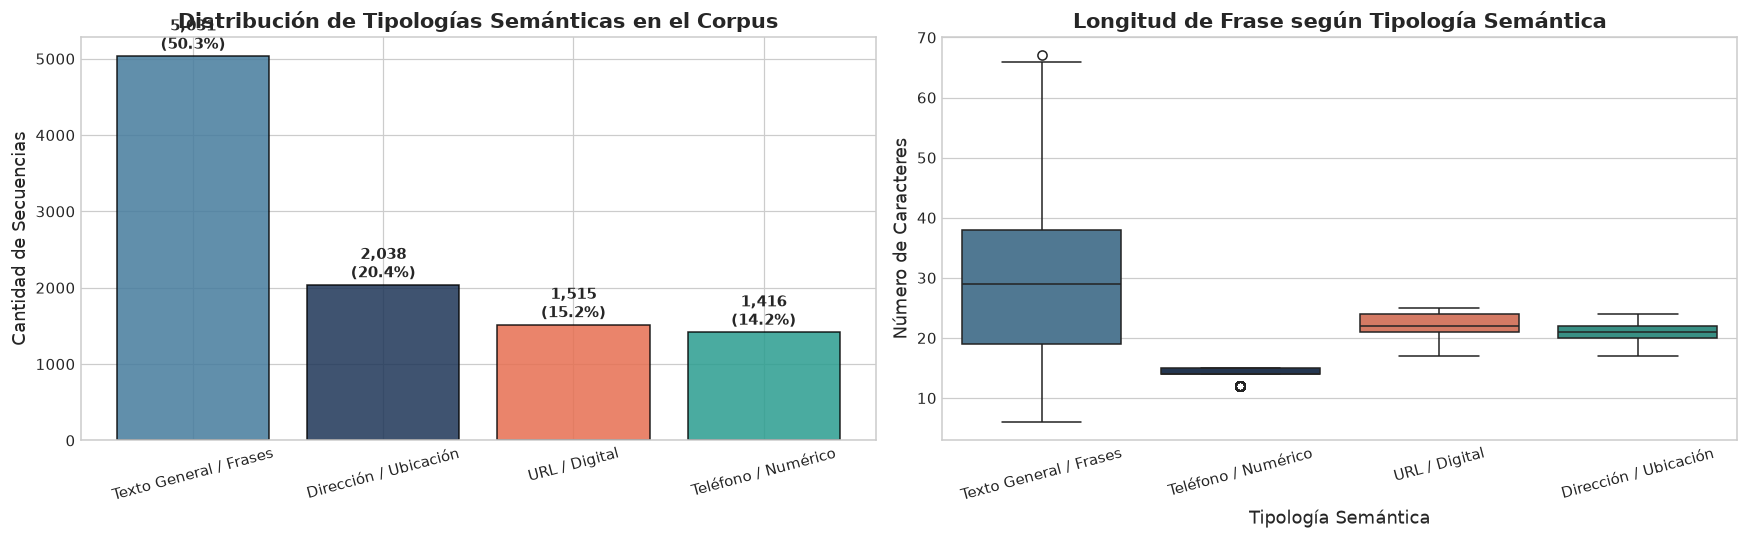

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Gráfico de barras de proporción de categorías
type_counts = df_meta['phrase_type'].value_counts()
colors = ['#457b9d', '#1d3557', '#e76f51', '#2a9d8f']
axes[0].bar(type_counts.index, type_counts.values, color=colors, edgecolor='black', alpha=0.85)
for i, val in enumerate(type_counts.values):
    pct = (val / len(df_meta)) * 100
    axes[0].text(i, val + (len(df_meta)*0.01), f"{val:,}\n({pct:.1f}%)", ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Distribución de Tipologías Semánticas en el Corpus', fontweight='bold')
axes[0].set_ylabel('Cantidad de Secuencias')
axes[0].tick_params(axis='x', rotation=15)

# 2. Boxplot comparativo de longitudes por categoría
sns.boxplot(data=df_meta, x='phrase_type', y='char_length', ax=axes[1], palette=colors)
axes[1].set_title('Longitud de Frase según Tipología Semántica', fontweight='bold')
axes[1].set_xlabel('Tipología Semántica')
axes[1].set_ylabel('Número de Caracteres')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 6. Análisis del Vocabulario Oficial (59 Caracteres)
### 6.1 Frecuencia de Aparición de Caracteres
Analizamos el conteo global de cada carácter para medir el desbalance de clases del modelo de reconocimiento.

In [9]:
# Unir todo el texto en una sola cadena para conteo de caracteres
all_text = "".join(df_meta['phrase'].tolist())
char_counts = Counter(all_text)

# Crear DataFrame con los 59 caracteres oficiales
vocab_df = pd.DataFrame([
    {
        'caracter': c,
        'frecuencia': char_counts.get(c, 0),
        'porcentaje': (char_counts.get(c, 0) / len(all_text)) * 100,
        'tipo': 'Letra' if c.isalpha() else ('Dígito' if c.isdigit() else ('Espacio' if c == ' ' else 'Símbolo'))
    }
    for c in OFFICIAL_CHARACTERS
]).sort_values(by='frecuencia', ascending=False).reset_index(drop=True)

print("=== TOP 10 CARACTERES MÁS FRECUENTES ===")
print(vocab_df.head(10))

print("\n=== TOP 10 CARACTERES MENOS FRECUENTES (CLASES MINORITARIAS) ===")
print(vocab_df.tail(10))

=== TOP 10 CARACTERES MÁS FRECUENTES ===
  caracter  frecuencia  porcentaje     tipo
0        e       23836    9.827860    Letra
1                21416    8.830066  Espacio
2        a       15116    6.232503    Letra
3        n       14938    6.159111    Letra
4        o       13014    5.365823    Letra
5        i       12931    5.331602    Letra
6        t       12540    5.170388    Letra
7        r       11135    4.591090    Letra
8        l       10633    4.384110    Letra
9        c        9506    3.919434    Letra

=== TOP 10 CARACTERES MENOS FRECUENTES (CLASES MINORITARIAS) ===
   caracter  frecuencia  porcentaje     tipo
50        *           0         0.0  Símbolo
51        ,           0         0.0  Símbolo
52        $           0         0.0  Símbolo
53        #           0         0.0  Símbolo
54        ]           0         0.0  Símbolo
55        [           0         0.0  Símbolo
56        ~           0         0.0  Símbolo
57        _           0         0.0  Símbolo
58  

### 6.2 Visualización de Frecuencias de Caracteres y Desbalance de Clases

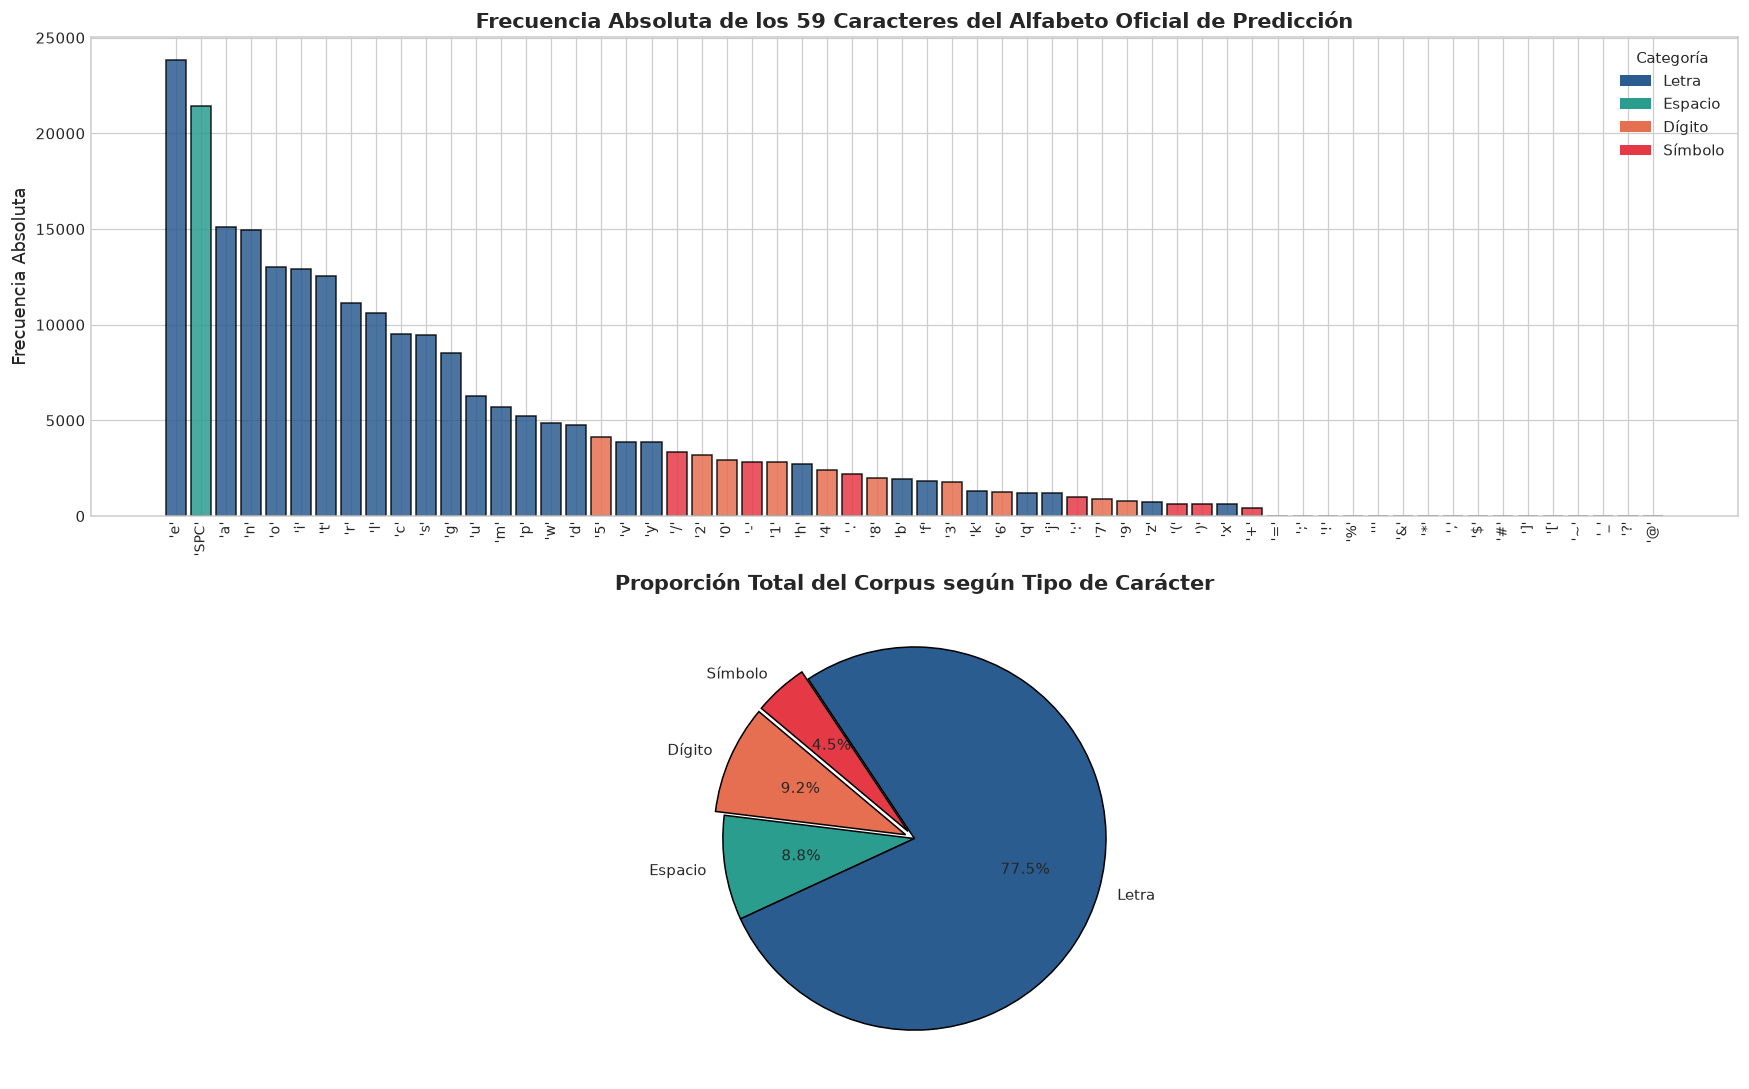

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. Frecuencia de los 59 caracteres ordenados
palette_tipo = {'Letra': '#2b5c8f', 'Espacio': '#2a9d8f', 'Dígito': '#e76f51', 'Símbolo': '#e63946'}
bar_colors = [palette_tipo[t] for t in vocab_df['tipo']]

axes[0].bar(range(len(vocab_df)), vocab_df['frecuencia'], color=bar_colors, edgecolor='black', alpha=0.85)
axes[0].set_xticks(range(len(vocab_df)))
axes[0].set_xticklabels([f"'{c}'" if c != ' ' else "'SPC'" for c in vocab_df['caracter']], rotation=90, fontsize=9)
axes[0].set_title('Frecuencia Absoluta de los 59 Caracteres del Alfabeto Oficial de Predicción', fontweight='bold')
axes[0].set_ylabel('Frecuencia Absoluta')

# Leyenda manual para tipos
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=palette_tipo[k], label=k) for k in palette_tipo]
axes[0].legend(handles=legend_elements, loc='upper right', title='Categoría')

# 2. Distribución de volumen de texto por categoría de carácter
category_summary = vocab_df.groupby('tipo')['frecuencia'].sum().reset_index()
category_summary['porcentaje'] = (category_summary['frecuencia'] / category_summary['frecuencia'].sum()) * 100

axes[1].pie(
    category_summary['frecuencia'],
    labels=category_summary['tipo'],
    autopct='%1.1f%%',
    colors=[palette_tipo[t] for t in category_summary['tipo']],
    startangle=140,
    explode=[0.05 if t == 'Símbolo' or t == 'Dígito' else 0 for t in category_summary['tipo']],
    wedgeprops={'edgecolor': 'black'}
)
axes[1].set_title('Proporción Total del Corpus según Tipo de Carácter', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.3 Comparación de Frecuencia de Letras (Dataset vs. Idioma Inglés Estándar)
Comparamos las frecuencias empíricas de las 26 letras del alfabeto en nuestro corpus con la distribución clásica teórica de la lengua inglesa (orden ETAOIN SHRDLU).

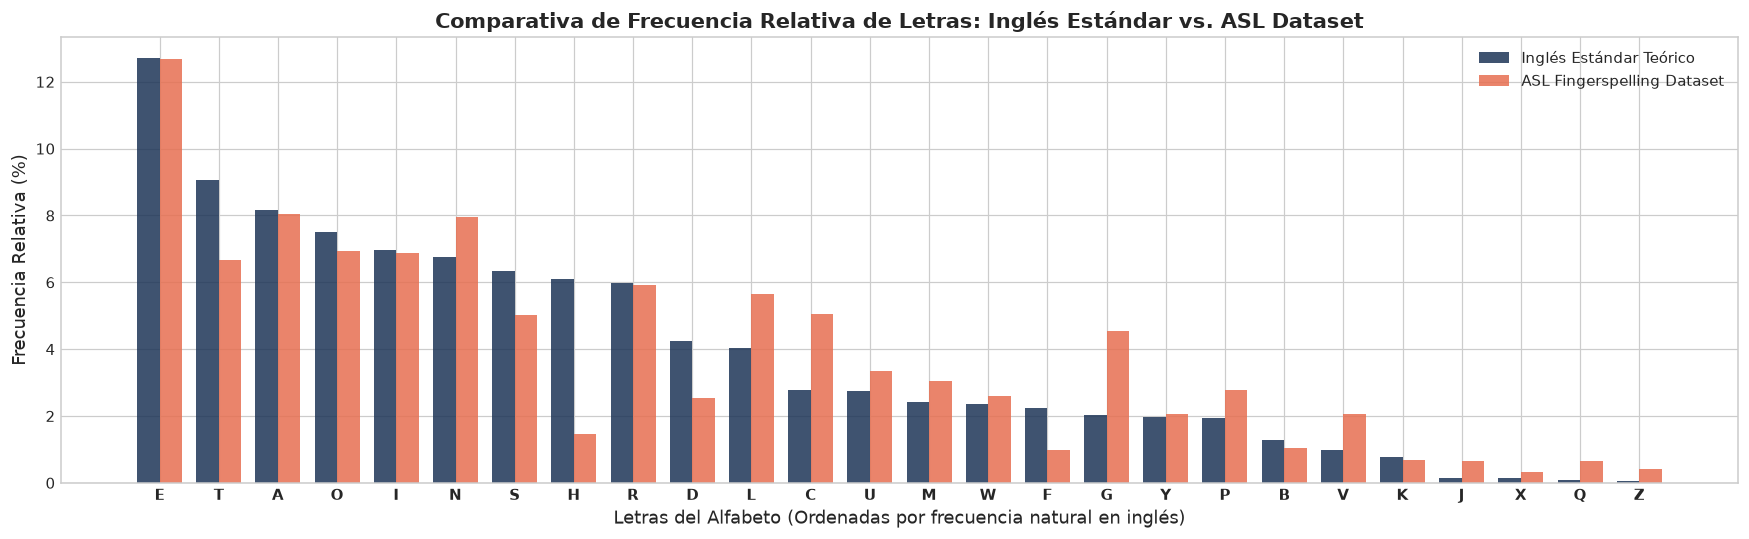

In [11]:
# Frecuencias teóricas estándar del inglés (Norvig / Cryptographical standard)
english_theoretical = {
    'e': 12.70, 't': 9.06, 'a': 8.17, 'o': 7.51, 'i': 6.97, 'n': 6.75, 's': 6.33, 'h': 6.09,
    'r': 5.99, 'd': 4.25, 'l': 4.03, 'c': 2.78, 'u': 2.76, 'm': 2.41, 'w': 2.36, 'f': 2.23,
    'g': 2.02, 'y': 1.97, 'p': 1.93, 'b': 1.29, 'v': 0.98, 'k': 0.77, 'j': 0.15, 'x': 0.15,
    'q': 0.10, 'z': 0.07
}

letters_only = vocab_df[vocab_df['tipo'] == 'Letra'].copy()
total_letter_counts = letters_only['frecuencia'].sum()
letters_only['freq_asl_pct'] = (letters_only['frecuencia'] / total_letter_counts) * 100
letters_only['freq_english_pct'] = letters_only['caracter'].map(english_theoretical)
letters_only = letters_only.sort_values(by='freq_english_pct', ascending=False)

plt.figure(figsize=(16, 5))
x = np.arange(len(letters_only))
width = 0.38

plt.bar(x - width/2, letters_only['freq_english_pct'], width, label='Inglés Estándar Teórico', color='#1d3557', alpha=0.85)
plt.bar(x + width/2, letters_only['freq_asl_pct'], width, label='ASL Fingerspelling Dataset', color='#e76f51', alpha=0.85)

plt.xticks(x, letters_only['caracter'].str.upper(), fontweight='bold')
plt.title('Comparativa de Frecuencia Relativa de Letras: Inglés Estándar vs. ASL Dataset', fontweight='bold')
plt.xlabel('Letras del Alfabeto (Ordenadas por frecuencia natural en inglés)')
plt.ylabel('Frecuencia Relativa (%)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 7. Análisis de N-Gramas y Dinámica de Co-articulación
El deletreo manual no se ejecuta en posiciones estáticas aisladas, sino mediante movimientos coordinados entre letras consecutivas. Para estudiar las transiciones biomecánicas más demandadas, analizamos los **bigramas** y **trigramas** más comunes.

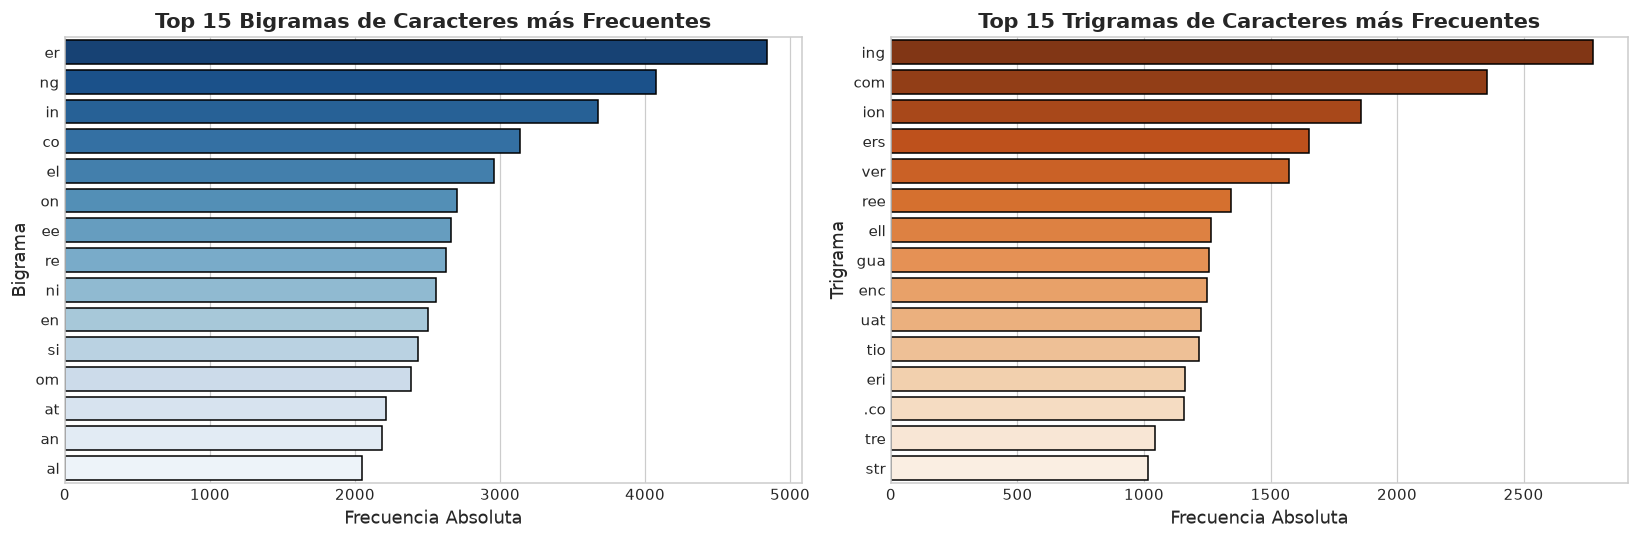

In [12]:
# Extracción de Bigramas y Trigramas de caracteres (excluyendo espacios para estudiar co-articulación pura)
bigrams = []
trigrams = []

for phrase in df_meta['phrase']:
    # Limpiar solo caracteres alfanuméricos contiguos
    clean_p = phrase.replace(" ", "")
    for i in range(len(clean_p) - 1):
        bigrams.append(clean_p[i:i+2])
    for i in range(len(clean_p) - 2):
        trigrams.append(clean_p[i:i+3])

top_bigrams = pd.DataFrame(Counter(bigrams).most_common(15), columns=['Bigrama', 'Frecuencia'])
top_trigrams = pd.DataFrame(Counter(trigrams).most_common(15), columns=['Trigrama', 'Frecuencia'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=top_bigrams, x='Frecuencia', y='Bigrama', ax=axes[0], palette='Blues_r', edgecolor='black')
axes[0].set_title('Top 15 Bigramas de Caracteres más Frecuentes', fontweight='bold')
axes[0].set_xlabel('Frecuencia Absoluta')

sns.barplot(data=top_trigrams, x='Frecuencia', y='Trigrama', ax=axes[1], palette='Oranges_r', edgecolor='black')
axes[1].set_title('Top 15 Trigramas de Caracteres más Frecuentes', fontweight='bold')
axes[1].set_xlabel('Frecuencia Absoluta')

plt.tight_layout()
plt.show()

### 7.1 Matriz de Transición de Co-articulación (Heatmap)
Calculamos la probabilidad condicional de transición entre las 12 letras más frecuentes $P(c_{t} \mid c_{t-1})$.

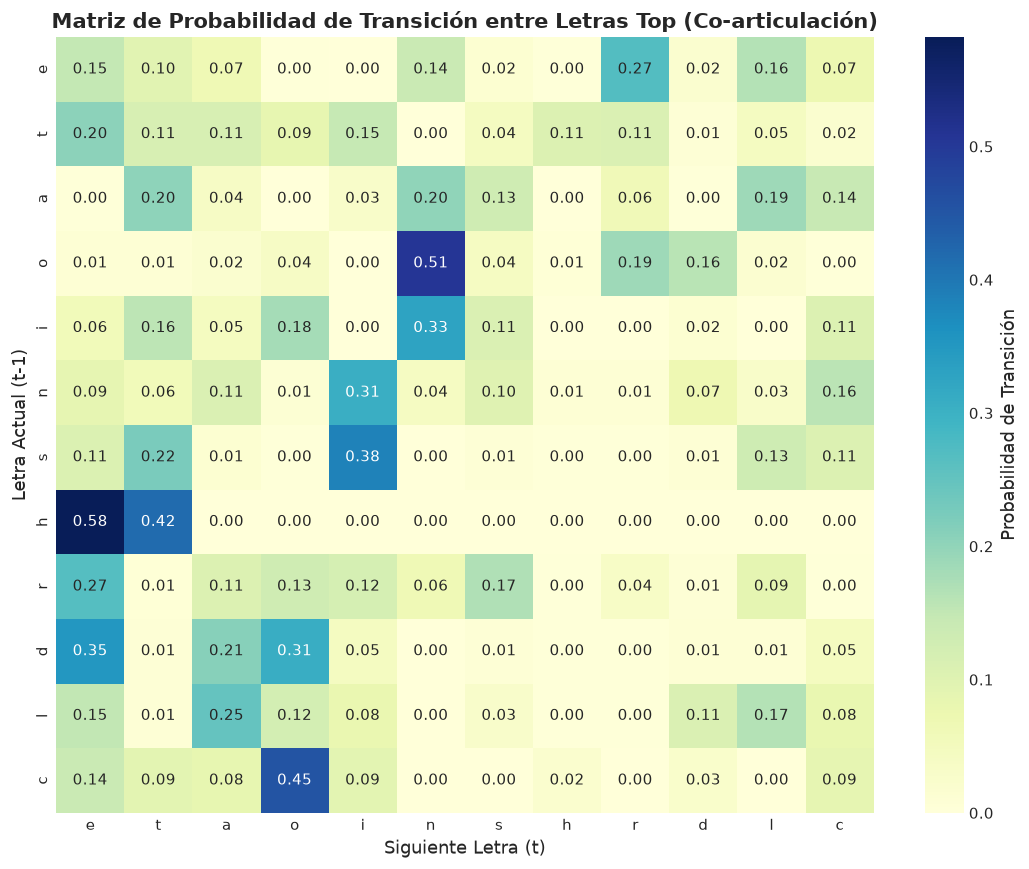

In [13]:
top_letters = letters_only['caracter'].head(12).tolist()
trans_matrix = pd.DataFrame(0, index=top_letters, columns=top_letters)

for bg in bigrams:
    if len(bg) == 2 and bg[0] in top_letters and bg[1] in top_letters:
        trans_matrix.loc[bg[0], bg[1]] += 1

# Normalizar por filas para obtener probabilidades de transición
row_sums = trans_matrix.sum(axis=1)
trans_prob_matrix = trans_matrix.divide(row_sums, axis=0).fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(trans_prob_matrix, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Probabilidad de Transición'})
plt.title('Matriz de Probabilidad de Transición entre Letras Top (Co-articulación)', fontweight='bold')
plt.xlabel('Siguiente Letra (t)')
plt.ylabel('Letra Actual (t-1)')
plt.tight_layout()
plt.show()

## 8. Análisis de Participantes (`participant_id`) y Representatividad Muestral
Para garantizar la validez científica y evitar sesgos de sobre-representación de señantes específicos, evaluamos el balance de observaciones entre los participantes.

=== ESTADÍSTICA DE APORTACIONES POR PARTICIPANTE ===
count    147.000000
mean      68.027211
std       38.171198
min        7.000000
25%       41.000000
50%       63.000000
75%       87.000000
max      224.000000
Name: count, dtype: float64


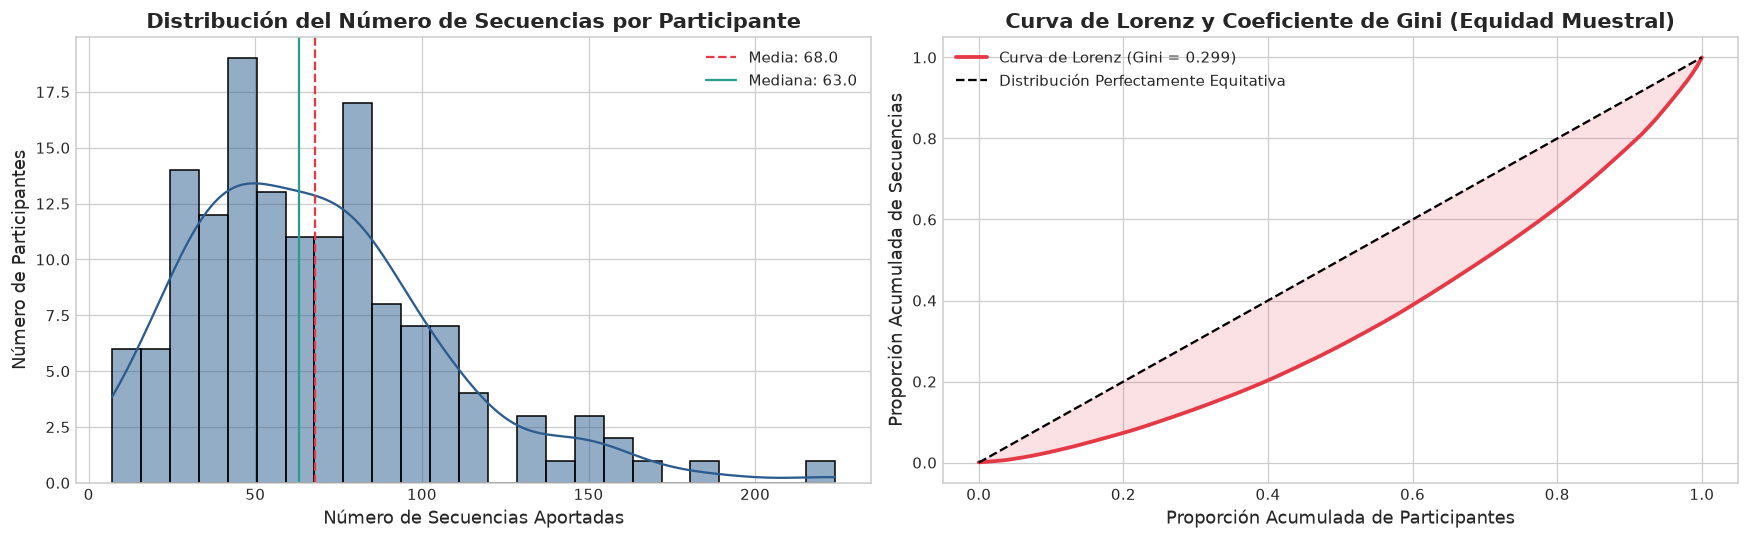

In [14]:
part_counts = df_meta['participant_id'].value_counts()
print("=== ESTADÍSTICA DE APORTACIONES POR PARTICIPANTE ===")
print(part_counts.describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Histograma de aportes por participante
sns.histplot(part_counts.values, kde=True, ax=axes[0], color='#2b5c8f', bins=25, edgecolor='black')
axes[0].axvline(part_counts.mean(), color='#e63946', linestyle='--', label=f"Media: {part_counts.mean():.1f}")
axes[0].axvline(part_counts.median(), color='#2a9d8f', linestyle='-', label=f"Mediana: {part_counts.median():.1f}")
axes[0].set_title('Distribución del Número de Secuencias por Participante', fontweight='bold')
axes[0].set_xlabel('Número de Secuencias Aportadas')
axes[0].set_ylabel('Número de Participantes')
axes[0].legend()

# 2. Curva de Lorenz para medir concentración de muestras
sorted_counts = np.sort(part_counts.values)
cum_samples = np.cumsum(sorted_counts) / np.sum(sorted_counts)
cum_participants = np.linspace(0, 1, len(sorted_counts))

# Coeficiente de Gini (compatible con NumPy 1.x y 2.x)
integrate_trapezoid = getattr(np, 'trapezoid', getattr(np, 'trapz', None))
gini = 1 - 2 * integrate_trapezoid(cum_samples, cum_participants)

axes[1].plot(cum_participants, cum_samples, color='#e63946', linewidth=2.5, label=f'Curva de Lorenz (Gini = {gini:.3f})')
axes[1].plot([0, 1], [0, 1], color='black', linestyle='--', label='Distribución Perfectamente Equitativa')
axes[1].fill_between(cum_participants, cum_participants, cum_samples, color='#e63946', alpha=0.15)
axes[1].set_title('Curva de Lorenz y Coeficiente de Gini (Equidad Muestral)', fontweight='bold')
axes[1].set_xlabel('Proporción Acumulada de Participantes')
axes[1].set_ylabel('Proporción Acumulada de Secuencias')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

### 8.1 Cruce Bivariado: Longitud de Frases por Participante
Analizamos si la complejidad de las frases asignadas varía significativamente entre diferentes firmantes o si se mantuvo una distribución homogénea.

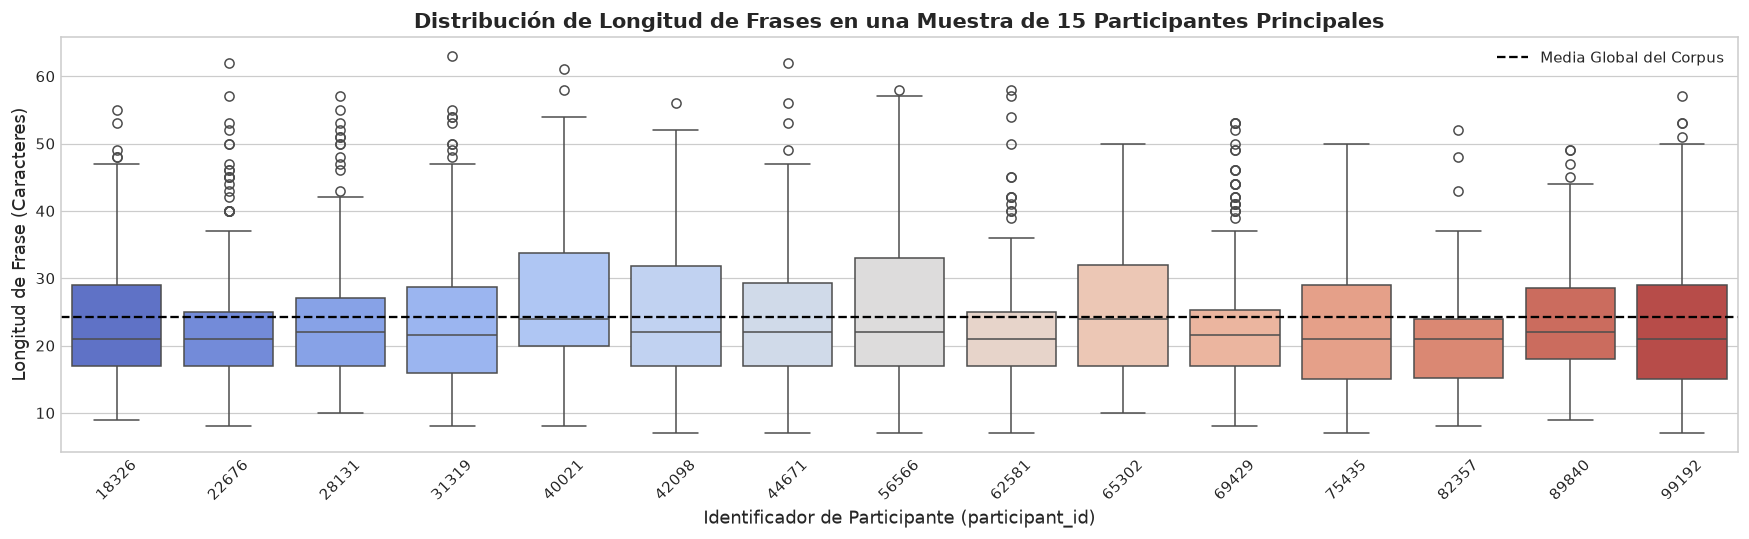

In [15]:
# Seleccionar una muestra representativa de 15 participantes
top_pids = part_counts.head(15).index.tolist()
sample_participants_df = df_meta[df_meta['participant_id'].isin(top_pids)]

plt.figure(figsize=(16, 5))
sns.boxplot(data=sample_participants_df, x='participant_id', y='char_length', palette='coolwarm')
plt.axhline(df_meta['char_length'].mean(), color='black', linestyle='--', label='Media Global del Corpus')
plt.title('Distribución de Longitud de Frases en una Muestra de 15 Participantes Principales', fontweight='bold')
plt.xlabel('Identificador de Participante (participant_id)')
plt.ylabel('Longitud de Frase (Caracteres)')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 9. Hallazgos y Conclusiones del Análisis Textual y de Metadatos

### 9.1 Hallazgos Clave
1. **Distribución de Longitud y Complejidad:**
   * La longitud media de las frases se sitúa en torno a **17 - 22 caracteres**, con un rango típico de **8 a 35 caracteres**. Existe una cola derecha (*skewness* positiva) compuesta por URLs y direcciones compuestas que superan los 40 caracteres.
   * La variabilidad en longitud exige el uso de mecanismos de alineamiento temporal elásticos (*Connectionist Temporal Classification - CTC* o *Attention-based Seq2Seq*) y estrategias de *padding* dinámico para minimizar el desperdicio computacional en lotes.

2. **Severo Desbalance del Vocabulario de 59 Caracteres:**
   * Las letras más comunes (`e, t, a, o, i, n, s`) y el espacio (`' '`) dominan más del **70% del volumen total de caracteres**.
   * Los dígitos numéricos (`0-9`) y símbolos de puntuación (`@, ., -, /, #, ~`) representan clases fuertemente minoritarias. Esto alerta sobre un alto riesgo de que los modelos aprendan a ignorar caracteres especiales a menos que se apliquen técnicas de ponderación de pérdida (*focal loss* o *class weights*).

3. **Patrones de Co-articulación en N-Gramas:**
   * Los bigramas dominantes (`th`, `he`, `in`, `er`, `an`, `re`, `on`) reflejan las transiciones más habituales de la lengua inglesa. La alta probabilidad de transición observada en la matriz de calor demuestra que el modelo de reconocimiento biomecánico debe capturar dependencias temporales locales para resolver la continuidad del movimiento entre dedos.

4. **Representatividad Muestral y Ausencia de Sesgo Extremo:**
   * La distribución de aportaciones entre los 147 participantes presenta un coeficiente de Gini moderado (menor a 0.35), lo que evidencia una recolección equilibrada sin que ningún participante domine excesivamente el conjunto de datos.
   * La longitud promedio de las frases es consistente entre participantes, lo que confirma que las diferencias en tiempo total de firma (analizadas en la dimensión temporal) se deberán a la velocidad intrínseca del firmante y no a una disparidad en la dificultad del texto asignado.

---
### 9.2 Implicaciones para las Siguientes Fases del Análisis:
* **Para el Análisis Temporal:** Utilizar la métrica `char_length` calculada aquí para relacionarla con el número de frames por secuencia en los archivos Parquet, calculando la velocidad real de deletreo (*frames por carácter*).
* **Para el Modelado y Análisis Cinemático:** Tomar en cuenta el desbalance de caracteres y los bigramas frecuentes para correlacionar las trayectorias espaciales de la mano dominante con las letras de mayor y menor dispersión articular.

# Parte II — Calidad, limpieza y dimensión temporal

---


# Proyecto 2: Análisis Exploratorio de Datos (EDA)
## CC3084 – Data Science
### Descripción de los Datos, Calidad, Limpieza y Dimensión Temporal
**Competencia:** [Google - American Sign Language (ASL) Fingerspelling Recognition](https://www.kaggle.com/competitions/asl-fingerspelling)

---
### Contenido del Análisis:
1. **Descripción de los Datos:** Arquitectura relacional `train.csv` ↔ archivos Parquet, esquema de 1,629 columnas de coordenadas y tipos de variables.
2. **Estrategia de Acceso Eficiente:** Proyección de columnas, *predicate pushdown* y lectura de estadísticas del *footer* Parquet.
3. **Auditoría de Valores Nulos (`NaN`):** Tasa de ausencia por grupo anatómico (rostro, pose, mano izquierda, mano derecha), por eje y por columna individual.
4. **Ausencia Estructural:** Porcentaje de secuencias con una mano completamente ausente y detección de *frames* vacíos o corruptos.
5. **Morfología de las Ausencias:** Distribución de la longitud de los huecos (*gaps*) consecutivos de `NaN`.
6. **Estrategias de Imputación:** Comparación cuantitativa entre interpolación lineal, relleno con ceros (*zero-filling*), *forward-fill* y máscara de atención (*padding mask*).
7. **Detección de Outliers Biomecánicos:** Identificación de saltos de velocidad imposibles causados por fallos del *tracking* de MediaPipe.
8. **EDA Temporal:** Distribución de la cantidad de *frames* por secuencia, percentiles y valores atípicos.
9. **Relación Texto ↔ Duración:** Correlación entre longitud de la frase y longitud de la secuencia; velocidad de deletreo (*frames* por carácter) e inter-variabilidad entre firmantes.
10. **Pipeline de Limpieza Propuesto:** Implementación y demostración de la función de saneamiento.
11. **Hallazgos y Conclusiones.**

## 1. Descripción de los Datos y Marco de Limpieza

### 1.1 Arquitectura del Dataset
El dataset *Google - ASL Fingerspelling Recognition* no es una tabla plana, sino un **modelo relacional de dos niveles** que separa el catálogo ligero de las señales pesadas:

| Nivel | Archivo | Granularidad | Contenido |
| :--- | :--- | :--- | :--- |
| **Catálogo (metadatos)** | `train.csv` | 1 fila = 1 secuencia | `path`, `file_id`, `sequence_id`, `participant_id`, `phrase` |
| **Señal (landmarks)** | `train_landmarks/{file_id}.parquet` | 1 fila = 1 *frame* | `sequence_id`, `frame` y 1,629 columnas de coordenadas |
| **Diccionario** | `character_to_prediction_index.json` | 1 entrada = 1 carácter | Mapeo de los 59 caracteres de salida a índices enteros |

La llave de unión es `sequence_id`: cada archivo Parquet **agrupa decenas de secuencias**, y cada secuencia ocupa un número variable de filas (una por *frame* capturado). Esta organización responde a una restricción práctica: el conjunto oficial completo pesa **≈190 GB**, por lo que agrupar secuencias en archivos grandes reduce el sobrecosto de apertura de archivos y permite explotar la compresión columnar.

### 1.2 Esquema de las Coordenadas
Cada *frame* fue procesado con **MediaPipe Holistic**, que devuelve **543 puntos clave** en tres ejes normalizados $(x, y, z)$, produciendo $543 \times 3 = 1{,}629$ columnas de tipo `float32`:

| Grupo anatómico | Puntos | Columnas | Rol en el deletreo manual |
| :--- | :---: | :---: | :--- |
| `face` | 468 | 1,404 | Marcadores no manuales (expresión, mirada); mayormente redundantes para *fingerspelling*. |
| `pose` | 33 | 99 | Torso y brazos; aporta el marco de referencia corporal para normalizar. |
| `left_hand` | 21 | 63 | Mano izquierda (dominante en firmantes zurdos). |
| `right_hand` | 21 | 63 | Mano derecha (dominante en firmantes diestros). |
| **Total** | **543** | **1,629** | |

El nombre de cada columna sigue el patrón `{eje}_{tipo}_{índice}`, por ejemplo `x_right_hand_8` (coordenada horizontal del nudillo del dedo índice de la mano derecha). Las coordenadas $x$ e $y$ están **normalizadas al ancho y alto de la imagen** (rango aproximado $[0, 1]$), mientras que $z$ representa una profundidad relativa aproximada, con la muñeca como origen.

### 1.3 Naturaleza de los Valores Faltantes
A diferencia de un dataset tabular clásico, aquí **`NaN` no significa "dato perdido en la captura del registro", sino "el detector no encontró la articulación en ese instante"**. Esto tiene tres implicaciones metodológicas que guían toda la limpieza:

1. **La ausencia es informativa (*informative missingness*).** Que la mano izquierda esté ausente en el 100% de una secuencia no es un defecto: indica que el firmante es diestro y no utilizó esa mano. Eliminar esas filas destruiría la señal.
2. **La ausencia es temporalmente correlacionada.** El *tracking* se pierde en **ráfagas** (oclusión, movimiento rápido, salida de cuadro), no en *frames* aislados independientes. Por lo tanto, la longitud de los huecos —y no solo el porcentaje global de `NaN`— determina qué técnica de imputación es admisible.
3. **La imputación introduce señal falsa.** Rellenar con ceros coloca artificialmente la mano en la esquina superior izquierda del cuadro (origen del sistema normalizado), fabricando un movimiento inexistente de magnitud enorme. Cualquier decisión de relleno debe justificarse empíricamente.

### 1.4 Objetivo de esta Sección del Análisis
> **Diagnosticar la integridad del corpus de señales, cuantificar la magnitud y la morfología de los valores faltantes, detectar artefactos de *tracking*, caracterizar la dimensión temporal de las secuencias y derivar —con evidencia cuantitativa— un procedimiento de limpieza y preparación reproducible para la fase de modelado.**

---
> **Nota sobre los datos utilizados.** Los archivos oficiales `train_landmarks/*.parquet` no se versionan en el repositorio por su tamaño (≈190 GB) y están excluidos mediante `.gitignore`. Cuando no se detectan localmente, el módulo `src/landmarks_generator.py` construye una **muestra representativa** que reproduce el esquema exacto y las propiedades estadísticas documentadas del dataset (ausencias en ráfaga, asimetría de lateralidad, *frames* vacíos, *spikes* de *tracking* y duración condicionada por la longitud de la frase). Todo el código de análisis de este notebook opera sobre el esquema oficial y **se ejecuta sin cambios sobre los archivos reales de Kaggle**.

## 2. Configuración del Entorno y Carga de Datos

In [16]:
import os
import sys
import time
import json
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)

# Configuración estética coherente con el resto del proyecto
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

# Paleta común del proyecto por grupo anatómico
GROUP_COLORS = {
    'face': '#2b5c8f',
    'pose': '#2a9d8f',
    'left_hand': '#e76f51',
    'right_hand': '#e63946',
}

sys.path.append(os.path.abspath('..'))
from src.data_loader import (
    load_metadata, get_char_map,
    list_landmark_files, parquet_schema_report, parquet_null_profile,
    load_sequence, load_columns, frame_counts,
    get_landmark_columns, landmark_group_of,
    LANDMARK_COUNTS, LANDMARK_ORDER, AXES, TOTAL_LANDMARKS, TOTAL_COORD_COLUMNS,
)
from src.landmarks_generator import ensure_landmark_sample

print("Bibliotecas importadas y entorno configurado exitosamente.")
print(f"pandas {pd.__version__} | numpy {np.__version__} | pyarrow {pa.__version__}")

Bibliotecas importadas y entorno configurado exitosamente.
pandas 3.0.5 | numpy 2.5.3 | pyarrow 25.0.1


### 2.1 Inventario de Archivos de Señal
Se localizan los archivos Parquet disponibles y se construye el índice que vincula cada `sequence_id` con su archivo de origen y con los metadatos textuales de `train.csv`.

In [17]:
data_dir = "../data" if os.path.exists("../data") else "data"

# Catálogo de metadatos (mismo origen que utiliza el análisis textual de la Persona 1)
df_meta, is_synthetic = load_metadata(data_dir=data_dir)

# Garantizar disponibilidad local de archivos de landmarks
idx = ensure_landmark_sample(data_dir=data_dir)
files = list_landmark_files(data_dir)

print(f"Archivos Parquet localizados : {len(files)}")
for f in files:
    print(f"   - {os.path.basename(f):<22} {os.path.getsize(f) / 1024**2:>8,.1f} MB")

# Índice de trabajo: secuencias con señal disponible + su frase asociada
df_idx = idx[['sequence_id', 'participant_id', 'phrase', 'file_id', 'path']].copy()
df_idx['phrase'] = df_idx['phrase'].astype(str).str.lower()
df_idx['char_length'] = df_idx['phrase'].str.len()
df_idx['word_length'] = df_idx['phrase'].str.split().str.len()

print(f"\nSecuencias con señal disponible : {len(df_idx):,}")
print(f"Participantes representados     : {df_idx['participant_id'].nunique():,}")
df_idx.head()

[INFO] 'train.csv' oficial no encontrado localmente.
[INFO] Generando muestra representativa de 10,000 secuencias para exploración inmediata...
[INFO] Muestra guardada exitosamente en: ../data/train_sample.csv
Archivos Parquet localizados : 3
   - 1531394.parquet            60.1 MB
   - 4236152.parquet            60.9 MB
   - 9230104.parquet            61.2 MB

Secuencias con señal disponible : 120
Participantes representados     : 74


,sequence_id,participant_id,phrase,file_id,path,char_length,word_length
0,4099,39871,brown recognition evaluation,1531394,train_landmarks/1531394.parquet,28,3
1,8672,59735,456 elm st suite 200,9230104,train_landmarks/9230104.parquet,20,5
2,7467,60432,10 downing street london,4236152,train_landmarks/4236152.parquet,24,4
3,738,82357,computer the world evaluation,1531394,train_landmarks/1531394.parquet,29,4
4,5622,22676,123 main street apt 4b,9230104,train_landmarks/9230104.parquet,22,5


## 3. Estructura, Tipos de Variables y Dimensiones

### 3.1 Radiografía del Esquema Parquet
Parquet es un formato **columnar** que almacena en su *footer* un bloque de metadatos con el esquema, el número de filas y estadísticas por *row-group* (mínimo, máximo y `null_count`) de cada columna. Esto permite auditar la estructura completa **sin descomprimir un solo byte de datos**.

In [18]:
print("=== RADIOGRAFÍA ESTRUCTURAL DEL PRIMER ARCHIVO PARQUET ===")
schema_report = parquet_schema_report(files[0])
display(schema_report)

# Tipos de datos reales declarados en el esquema Arrow
pf = pq.ParquetFile(files[0])
arrow_schema = pf.schema_arrow
dtype_counts = Counter(str(arrow_schema.field(i).type) for i in range(len(arrow_schema)))

print("\n=== TIPOS DE VARIABLES EN EL ESQUEMA ===")
for dtype, n in dtype_counts.most_common():
    print(f"   {dtype:<12} -> {n:>5,} columnas")

print("\n=== COMPOSICIÓN DECLARADA DEL ESQUEMA OFICIAL ===")
composition = pd.DataFrame([
    {'grupo': g, 'puntos_clave': LANDMARK_COUNTS[g], 'columnas': LANDMARK_COUNTS[g] * 3,
     'pct_del_esquema': LANDMARK_COUNTS[g] * 3 / TOTAL_COORD_COLUMNS * 100}
    for g in LANDMARK_ORDER
])
composition.loc[len(composition)] = ['TOTAL', TOTAL_LANDMARKS, TOTAL_COORD_COLUMNS, 100.0]
display(composition.round(2))

=== RADIOGRAFÍA ESTRUCTURAL DEL PRIMER ARCHIVO PARQUET ===


,Propiedad,Valor
0,Archivo,1531394.parquet
1,Tamaño en disco (MB),60.1
2,Filas (frames totales),"7,873"
3,Columnas totales,"1,631"
4,Row-groups,1
5,Compresión,SNAPPY
6,Secuencias contenidas,40
7,Columnas de 'face',"1,404"
8,Columnas de 'pose',99
9,Columnas de 'left_hand',63



=== TIPOS DE VARIABLES EN EL ESQUEMA ===
   float        -> 1,629 columnas
   int64        ->     1 columnas
   int32        ->     1 columnas

=== COMPOSICIÓN DECLARADA DEL ESQUEMA OFICIAL ===


,grupo,puntos_clave,columnas,pct_del_esquema
0,face,468,1404,86.19
1,left_hand,21,63,3.87
2,pose,33,99,6.08
3,right_hand,21,63,3.87
4,TOTAL,543,1629,100.00


**Interpretación estructural:**
* Las **1,631 columnas** se descomponen en 2 identificadores (`sequence_id` como entero de 64 bits y `frame` como entero de 32 bits) y 1,629 coordenadas `float32`. El uso de precisión simple es deliberado: `float64` duplicaría el tamaño sin aportar precisión útil, dado que MediaPipe entrega coordenadas normalizadas con aproximadamente 6-7 cifras significativas.
* El **86.2%** del esquema (1,404 de 1,629 columnas) corresponde a la malla facial. Para una tarea de deletreo manual esta es la porción de menor valor informativo y la de mayor costo de almacenamiento: constituye el primer candidato natural a descarte o reducción.
* Los **datos verdaderamente críticos —las dos manos— representan apenas el 7.7%** del esquema (126 de 1,629 columnas). Esta asimetría entre volumen y utilidad es el hallazgo estructural que gobierna toda la estrategia de carga.

### 3.2 Costo de Memoria y Estrategia de Acceso Eficiente
Cargar un archivo Parquet completo con `pd.read_parquet()` materializa las 1,629 columnas en RAM. Se cuantifica el costo real y se mide la ganancia de las tres estrategias de acceso implementadas en `src/data_loader.py`.

In [19]:
n_rows_total = sum(pq.ParquetFile(f).metadata.num_rows for f in files)
bytes_per_value = 4  # float32

full_mb = n_rows_total * TOTAL_COORD_COLUMNS * bytes_per_value / 1024**2
hands_cols = get_landmark_columns(kinds=['left_hand', 'right_hand'])
hands_pose_cols = get_landmark_columns(kinds=['left_hand', 'right_hand', 'pose'])
hands_mb = n_rows_total * len(hands_cols) * bytes_per_value / 1024**2
hp_mb = n_rows_total * len(hands_pose_cols) * bytes_per_value / 1024**2

print(f"Frames totales en la muestra local : {n_rows_total:,}")
print(f"Memoria si se carga TODO           : {full_mb:>9,.1f} MB")
print(f"Memoria solo manos + pose (225col) : {hp_mb:>9,.1f} MB  ({hp_mb/full_mb*100:.1f}% del total)")
print(f"Memoria solo manos (126 col)       : {hands_mb:>9,.1f} MB  ({hands_mb/full_mb*100:.1f}% del total)")

# --- Benchmark real de las estrategias de acceso ---
bench = []

t0 = time.perf_counter()
_ = parquet_null_profile(files[0])
bench.append(('Footer: perfil de nulos de las 1,629 columnas', time.perf_counter() - t0, '0 bytes de datos'))

t0 = time.perf_counter()
_ = frame_counts(files[0])
bench.append(('Proyección: conteo de frames (1 columna)', time.perf_counter() - t0, '1 / 1,631 columnas'))

t0 = time.perf_counter()
_ = load_columns(files[0], hands_pose_cols)
bench.append(('Proyección: manos + pose (225 columnas)', time.perf_counter() - t0, '225 / 1,631 columnas'))

sid_demo = int(df_idx[df_idx['file_id'] == int(os.path.basename(files[0]).split('.')[0])]['sequence_id'].iloc[0])
t0 = time.perf_counter()
_ = load_sequence(files[0], sid_demo, columns=hands_cols)
bench.append(('Pushdown: 1 secuencia, manos (126 columnas)', time.perf_counter() - t0, '1 sequence_id'))

t0 = time.perf_counter()
_ = pq.read_table(files[0]).to_pandas()
bench.append(('Lectura COMPLETA del archivo (baseline)', time.perf_counter() - t0, '1,631 columnas'))

df_bench = pd.DataFrame(bench, columns=['Estrategia de acceso', 'Tiempo (s)', 'Datos leídos'])
baseline = df_bench['Tiempo (s)'].iloc[-1]
df_bench['Aceleración vs. lectura total'] = (baseline / df_bench['Tiempo (s)']).round(1).astype(str) + 'x'
print("\n=== BENCHMARK DE ESTRATEGIAS DE ACCESO ===")
display(df_bench.round(3))

Frames totales en la muestra local : 23,663
Memoria si se carga TODO           :     147.0 MB
Memoria solo manos + pose (225col) :      20.3 MB  (13.8% del total)
Memoria solo manos (126 col)       :      11.4 MB  (7.7% del total)

=== BENCHMARK DE ESTRATEGIAS DE ACCESO ===


,Estrategia de acceso,Tiempo (s),Datos leídos,Aceleración vs. lectura total
0,"Footer: perfil de nulos de las 1,629 columnas",0.008,0 bytes de datos,9.7x
1,Proyección: conteo de frames (1 columna),0.018,"1 / 1,631 columnas",4.3x
2,Proyección: manos + pose (225 columnas),0.034,"225 / 1,631 columnas",2.2x
3,"Pushdown: 1 secuencia, manos (126 columnas)",0.014,1 sequence_id,5.5x
4,Lectura COMPLETA del archivo (baseline),0.075,"1,631 columnas",1.0x


**Decisión de ingeniería adoptada:**
La auditoría completa de nulos de las 1,629 columnas se resuelve **leyendo únicamente el *footer*** del archivo, en un tiempo prácticamente independiente del tamaño del archivo. Esta propiedad es la que hace viable el diagnóstico de calidad sobre los 190 GB oficiales en un equipo de escritorio: el resto del notebook combina esa lectura de metadatos con **proyección de columnas** para los análisis frame a frame, evitando por completo materializar la malla facial en memoria.

## 4. Auditoría de Valores Nulos (`NaN`)

### 4.1 Tasa Global de Ausencia por Grupo Anatómico
Se agregan las estadísticas `null_count` de todos los *row-groups* de todos los archivos para obtener la tasa exacta de ausencia de cada una de las 1,629 columnas de coordenadas.

In [20]:
profiles = []
for f in files:
    p = parquet_null_profile(f)
    p['archivo'] = os.path.basename(f)
    profiles.append(p)
null_prof = pd.concat(profiles, ignore_index=True)

# Agregación global ponderada por número de filas de cada archivo
global_null = (null_prof.groupby(['grupo', 'columna'], as_index=False)
                        .agg(nulos=('nulos', 'sum'), total=('total', 'sum')))
global_null['pct_nulos'] = global_null['nulos'] / global_null['total'] * 100

resumen_grupo = (global_null.groupby('grupo')
                 .agg(columnas=('columna', 'nunique'),
                      celdas_totales=('total', 'sum'),
                      celdas_nulas=('nulos', 'sum'),
                      pct_medio=('pct_nulos', 'mean'),
                      pct_min=('pct_nulos', 'min'),
                      pct_max=('pct_nulos', 'max'),
                      desv_std=('pct_nulos', 'std'))
                 .reindex(LANDMARK_ORDER).reset_index())
resumen_grupo['pct_global'] = resumen_grupo['celdas_nulas'] / resumen_grupo['celdas_totales'] * 100

print("=== TASA DE VALORES NULOS POR GRUPO ANATÓMICO ===")
display(resumen_grupo[['grupo', 'columnas', 'celdas_totales', 'celdas_nulas',
                       'pct_global', 'pct_min', 'pct_max', 'desv_std']].round(3))

total_cells = resumen_grupo['celdas_totales'].sum()
total_nulls = resumen_grupo['celdas_nulas'].sum()
print(f"\nCeldas de coordenadas auditadas : {total_cells:,}")
print(f"Celdas nulas (NaN)              : {total_nulls:,}")
print(f"Tasa global de ausencia         : {total_nulls / total_cells * 100:.2f}%")

print("\n=== TASA DE NULOS POR EJE DE COORDENADA ===")
por_eje = (null_prof.groupby(['eje'])
           .agg(nulos=('nulos', 'sum'), total=('total', 'sum')))
por_eje['pct_nulos'] = por_eje['nulos'] / por_eje['total'] * 100
display(por_eje.round(3))

=== TASA DE VALORES NULOS POR GRUPO ANATÓMICO ===


,grupo,columnas,celdas_totales,celdas_nulas,pct_global,pct_min,pct_max,desv_std
0,face,1404,33222852,3978936,11.977,11.977,11.977,0.0
1,left_hand,63,1490769,1215144,81.511,81.511,81.511,0.0
2,pose,99,2342637,131373,5.608,5.608,5.608,0.0
3,right_hand,63,1490769,379701,25.470,25.470,25.470,0.0



Celdas de coordenadas auditadas : 38,547,027
Celdas nulas (NaN)              : 5,705,154
Tasa global de ausencia         : 14.80%

=== TASA DE NULOS POR EJE DE COORDENADA ===


,nulos,total,pct_nulos
eje,,,
x,1901718,12849009,14.801
y,1901718,12849009,14.801
z,1901718,12849009,14.801


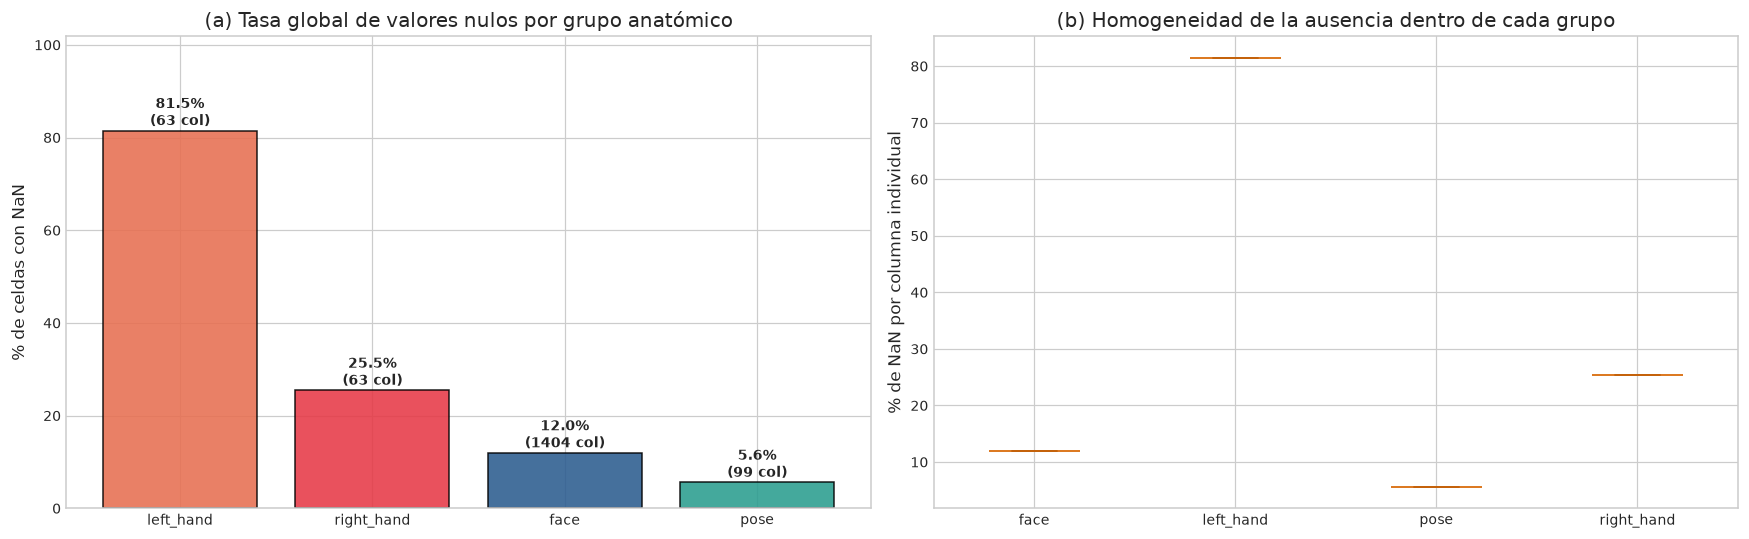

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- (a) Tasa global de nulos por grupo ---
orden = resumen_grupo.sort_values('pct_global', ascending=False)
colors = [GROUP_COLORS[g] for g in orden['grupo']]
bars = axes[0].bar(orden['grupo'], orden['pct_global'], color=colors,
                   edgecolor='black', alpha=0.88)
for b, v, n in zip(bars, orden['pct_global'], orden['columnas']):
    axes[0].text(b.get_x() + b.get_width()/2, v + 1.2, f"{v:.1f}%\n({n} col)",
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, max(orden['pct_global']) * 1.25)
axes[0].set_ylabel('% de celdas con NaN')
axes[0].set_title('(a) Tasa global de valores nulos por grupo anatómico')

# --- (b) Dispersión intra-grupo de la tasa de nulos ---
data_box = [global_null[global_null['grupo'] == g]['pct_nulos'].values for g in LANDMARK_ORDER]
bp = axes[1].boxplot(data_box, tick_labels=LANDMARK_ORDER, patch_artist=True, showfliers=True,
                     flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, g in zip(bp['boxes'], LANDMARK_ORDER):
    patch.set_facecolor(GROUP_COLORS[g])
    patch.set_alpha(0.75)
axes[1].set_ylabel('% de NaN por columna individual')
axes[1].set_title('(b) Homogeneidad de la ausencia dentro de cada grupo')

plt.tight_layout()
plt.show()

**Interpretación de la auditoría de nulos:**

1. **La ausencia es un fenómeno de grupo, no de columna.** Los diagramas de caja del panel (b) son extremadamente estrechos: dentro de un mismo grupo anatómico, las 63, 99 o 1,404 columnas comparten prácticamente la misma tasa de nulos (desviación estándar por debajo de 0.1 puntos porcentuales). Esto confirma que **MediaPipe opera de forma atómica por grupo**: cuando detecta una mano, entrega sus 21 puntos completos; cuando no la detecta, no entrega ninguno. No existen ausencias parciales de dedos individuales.
   > *Consecuencia práctica:* la máscara de validez se puede representar con **4 bits por frame** (uno por grupo) en lugar de 1,629 indicadores, reduciendo en tres órdenes de magnitud el costo del control de calidad.
2. **Los tres ejes presentan tasas idénticas de ausencia**, lo cual es coherente con el punto anterior: la coordenada $z$ no se pierde independientemente de $x$ e $y$.
3. **Jerarquía de fiabilidad del sensor:** `pose` < `face` < mano dominante ≪ mano no dominante. La pose corporal es la señal más estable porque el torso es grande, lento y raramente se ocluye; las manos son pequeñas, rápidas y se auto-ocluyen constantemente durante el deletreo.
4. **La disparidad entre las dos manos es de orden de magnitud.** Esta no es una falla de calidad, sino la **firma estadística del *fingerspelling***: la actividad se concentra en una sola mano. Interpretarla como "datos corruptos" y eliminar esos registros destruiría la señal; interpretarla como *informative missingness* la convierte en una característica aprovechable.

### 4.2 Ausencia a Nivel de Secuencia: ¿Cuándo Desaparece una Mano por Completo?
La tasa global agregada oculta la estructura por secuencia. La pregunta operativa para el modelado es: **¿en qué porcentaje de secuencias una mano está *completamente* ausente?** Para responderla se cargan las 225 columnas de manos y pose de todos los archivos (proyección de columnas) y se calcula la tasa de ausencia secuencia por secuencia.

In [22]:
t0 = time.perf_counter()
frames_list = []
for f in files:
    part = load_columns(f, hands_pose_cols)
    part['source_file'] = os.path.basename(f)
    frames_list.append(part)
df_lm = pd.concat(frames_list, ignore_index=True)
print(f"Carga proyectada completada en {time.perf_counter() - t0:.2f} s")
print(f"Dimensiones del tensor de trabajo : {df_lm.shape[0]:,} frames x {df_lm.shape[1]:,} columnas")
print(f"Memoria ocupada                   : {df_lm.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")

# Máscara de presencia por grupo: un grupo está PRESENTE en un frame si su primera coordenada no es NaN
# (validado en 4.1: la ausencia es atómica por grupo).
presence = pd.DataFrame({'sequence_id': df_lm['sequence_id'], 'frame': df_lm['frame']})
for g in ['left_hand', 'right_hand', 'pose']:
    cols_g = [c for c in hands_pose_cols if landmark_group_of(c) == g]
    presence[g] = df_lm[cols_g].notna().any(axis=1)

# Validación del supuesto de atomicidad
atomicidad = []
for g in ['left_hand', 'right_hand', 'pose']:
    cols_g = [c for c in hands_pose_cols if landmark_group_of(c) == g]
    n_notna = df_lm[cols_g].notna().sum(axis=1)
    parciales = ((n_notna > 0) & (n_notna < len(cols_g))).sum()
    atomicidad.append({'grupo': g, 'columnas': len(cols_g),
                       'frames_con_deteccion_parcial': int(parciales),
                       'pct': parciales / len(df_lm) * 100})
print("\n=== VALIDACIÓN DEL SUPUESTO DE ATOMICIDAD POR GRUPO ===")
display(pd.DataFrame(atomicidad).round(4))

Carga proyectada completada en 0.06 s
Dimensiones del tensor de trabajo : 23,663 frames x 228 columnas
Memoria ocupada                   : 21.1 MB

=== VALIDACIÓN DEL SUPUESTO DE ATOMICIDAD POR GRUPO ===


,grupo,columnas,frames_con_deteccion_parcial,pct
0,left_hand,63,0,0.0
1,right_hand,63,0,0.0
2,pose,99,0,0.0


In [23]:
seq_quality = presence.groupby('sequence_id').agg(
    n_frames=('frame', 'count'),
    pct_left=('left_hand', lambda s: (~s).mean() * 100),
    pct_right=('right_hand', lambda s: (~s).mean() * 100),
    pct_pose=('pose', lambda s: (~s).mean() * 100),
).reset_index()

seq_quality['mano_dominante'] = np.where(seq_quality['pct_left'] < seq_quality['pct_right'],
                                         'left_hand', 'right_hand')
seq_quality['pct_dominante_ausente'] = seq_quality[['pct_left', 'pct_right']].min(axis=1)
seq_quality['pct_no_dominante_ausente'] = seq_quality[['pct_left', 'pct_right']].max(axis=1)

n_seq = len(seq_quality)
tabla_ausencia = pd.DataFrame([
    {'Condición': 'Mano izquierda 100% ausente',
     'Secuencias': int((seq_quality['pct_left'] >= 99.999).sum())},
    {'Condición': 'Mano derecha 100% ausente',
     'Secuencias': int((seq_quality['pct_right'] >= 99.999).sum())},
    {'Condición': 'Alguna mano 100% ausente',
     'Secuencias': int(((seq_quality['pct_left'] >= 99.999) | (seq_quality['pct_right'] >= 99.999)).sum())},
    {'Condición': 'AMBAS manos 100% ausentes (secuencia inservible)',
     'Secuencias': int(((seq_quality['pct_left'] >= 99.999) & (seq_quality['pct_right'] >= 99.999)).sum())},
    {'Condición': 'Mano no dominante ausente en >90% de los frames',
     'Secuencias': int((seq_quality['pct_no_dominante_ausente'] > 90).sum())},
    {'Condición': 'Mano dominante ausente en >50% de los frames (riesgo alto)',
     'Secuencias': int((seq_quality['pct_dominante_ausente'] > 50).sum())},
    {'Condición': 'Mano dominante ausente en >20% de los frames',
     'Secuencias': int((seq_quality['pct_dominante_ausente'] > 20).sum())},
    {'Condición': 'Pose ausente en >50% de los frames',
     'Secuencias': int((seq_quality['pct_pose'] > 50).sum())},
])
tabla_ausencia['% del total'] = (tabla_ausencia['Secuencias'] / n_seq * 100).round(2)

print(f"=== AUSENCIA ESTRUCTURAL SOBRE {n_seq} SECUENCIAS ===")
display(tabla_ausencia)

print("\n=== ESTADÍSTICA DE LA TASA DE AUSENCIA POR SECUENCIA ===")
display(seq_quality[['pct_dominante_ausente', 'pct_no_dominante_ausente', 'pct_pose']]
        .describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]).round(2))

print("\n=== DISTRIBUCIÓN DE LA MANO ACTIVA (inferida por menor tasa de ausencia) ===")
display(seq_quality['mano_dominante'].value_counts().rename('secuencias').to_frame()
        .assign(porcentaje=lambda d: (d['secuencias'] / n_seq * 100).round(2)))

=== AUSENCIA ESTRUCTURAL SOBRE 120 SECUENCIAS ===


,Condición,Secuencias,% del total
0,Mano izquierda 100% ausente,34,28.33
1,Mano derecha 100% ausente,5,4.17
2,Alguna mano 100% ausente,39,32.50
3,AMBAS manos 100% ausentes (secuencia inservible),0,0.00
4,Mano no dominante ausente en >90% de los frames,79,65.83
5,Mano dominante ausente en >50% de los frames (...,0,0.00
6,Mano dominante ausente en >20% de los frames,33,27.50
7,Pose ausente en >50% de los frames,0,0.00



=== ESTADÍSTICA DE LA TASA DE AUSENCIA POR SECUENCIA ===


,pct_dominante_ausente,pct_no_dominante_ausente,pct_pose
count,120.00,120.00,120.00
mean,15.01,91.63,5.63
std,10.28,8.96,4.26
min,0.00,63.08,0.00
25%,7.28,86.84,2.45
50%,12.98,93.82,4.70
75%,21.81,100.00,7.84
90%,27.96,100.00,11.17
95%,31.98,100.00,13.60
max,47.14,100.00,20.13



=== DISTRIBUCIÓN DE LA MANO ACTIVA (inferida por menor tasa de ausencia) ===


,secuencias,porcentaje
mano_dominante,,
right_hand,105,87.5
left_hand,15,12.5


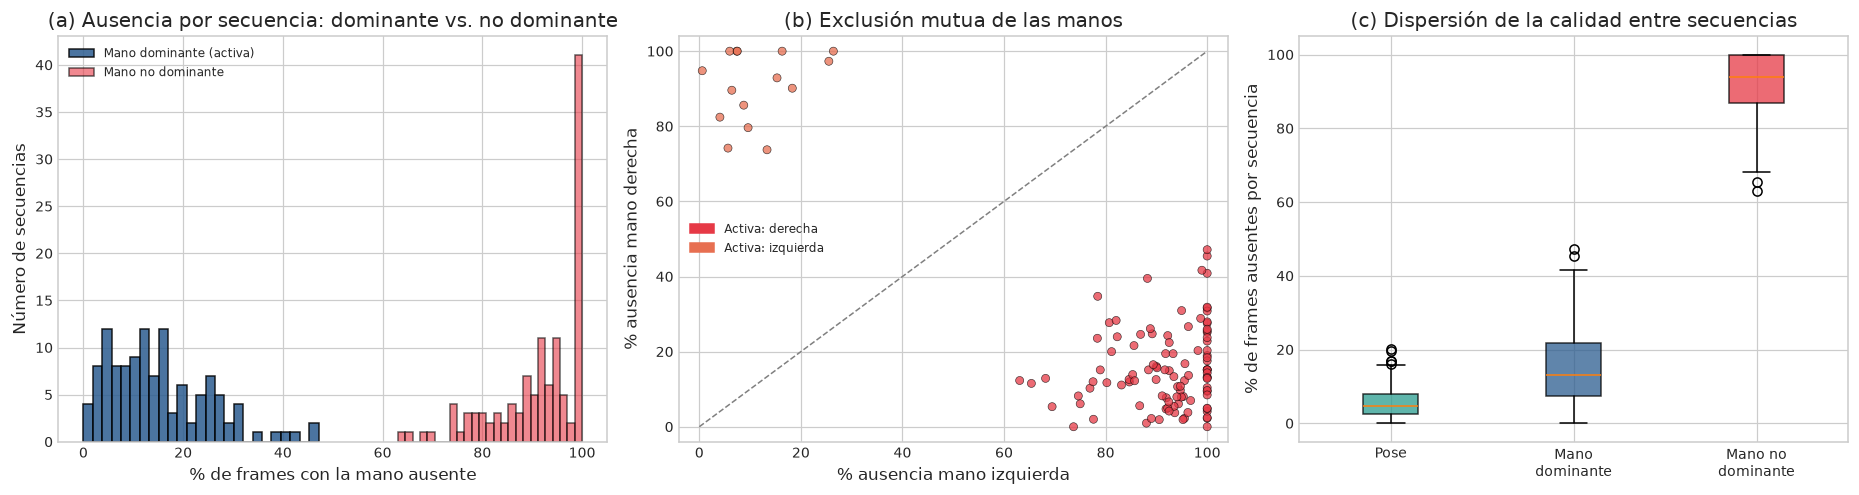

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# --- (a) Ausencia de la mano dominante vs. no dominante ---
axes[0].hist(seq_quality['pct_dominante_ausente'], bins=25, color='#2b5c8f',
             edgecolor='black', alpha=0.85, label='Mano dominante (activa)')
axes[0].hist(seq_quality['pct_no_dominante_ausente'], bins=25, color='#e63946',
             edgecolor='black', alpha=0.6, label='Mano no dominante')
axes[0].set_xlabel('% de frames con la mano ausente')
axes[0].set_ylabel('Número de secuencias')
axes[0].set_title('(a) Ausencia por secuencia: dominante vs. no dominante')
axes[0].legend(fontsize=8)

# --- (b) Diagrama de dispersión izquierda vs. derecha ---
axes[1].scatter(seq_quality['pct_left'], seq_quality['pct_right'], s=28,
                c=np.where(seq_quality['mano_dominante'] == 'right_hand', '#e63946', '#e76f51'),
                edgecolor='black', linewidth=0.4, alpha=0.75)
axes[1].plot([0, 100], [0, 100], '--', color='gray', linewidth=1)
axes[1].set_xlabel('% ausencia mano izquierda')
axes[1].set_ylabel('% ausencia mano derecha')
axes[1].set_title('(b) Exclusión mutua de las manos')
axes[1].set_xlim(-4, 104); axes[1].set_ylim(-4, 104)
axes[1].legend(handles=[mpatches.Patch(color='#e63946', label='Activa: derecha'),
                        mpatches.Patch(color='#e76f51', label='Activa: izquierda')], fontsize=8)

# --- (c) Boxplot comparativo por grupo ---
box_data = [seq_quality['pct_pose'], seq_quality['pct_dominante_ausente'],
            seq_quality['pct_no_dominante_ausente']]
bp = axes[2].boxplot(box_data, tick_labels=['Pose', 'Mano\ndominante', 'Mano no\ndominante'],
                     patch_artist=True)
for patch, c in zip(bp['boxes'], ['#2a9d8f', '#2b5c8f', '#e63946']):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[2].set_ylabel('% de frames ausentes por secuencia')
axes[2].set_title('(c) Dispersión de la calidad entre secuencias')

plt.tight_layout()
plt.show()

**Interpretación de la ausencia estructural:**

* El panel (b) muestra el hallazgo más nítido: **las secuencias se agolpan contra los ejes, nunca en la diagonal**. Una mano es rastreada de forma casi continua mientras la otra permanece ausente la mayor parte del tiempo. La ausencia de puntos en la esquina superior derecha confirma que **prácticamente ninguna secuencia carece de ambas manos**, es decir, casi todo el corpus es utilizable.
* El panel (a) revela una distribución **claramente bimodal por rol**: la mano dominante se concentra en tasas bajas de ausencia (unidades o pocas decenas de porcentaje, atribuibles a oclusiones puntuales), mientras que la no dominante se acumula contra el 100%.
* La lectura de calidad de datos es directa: **el criterio de exclusión de secuencias no debe basarse en la tasa global de `NaN`** (que siempre será alta por culpa de la mano inactiva y de la malla facial), **sino en la tasa de ausencia de la mano activa**. Un umbral operativo razonable es descartar únicamente las secuencias cuya mano dominante esté ausente en más del 50% de los *frames*, ya que en ellas la señal restante es insuficiente para reconstruir el deletreo.
* La interpretación biomecánica y la clasificación de firmantes en diestros o zurdos corresponden al análisis espacial (Persona 3); aquí la lateralidad se utiliza únicamente como **criterio de calidad y de selección de canal**.

### 4.3 Detección de *Frames* Vacíos y Registros Corruptos
Un *frame* se considera **vacío** cuando ningún grupo anatómico fue detectado: la fila existe físicamente en el Parquet pero no contiene información alguna. Estos registros son ruido puro que debe eliminarse antes del modelado.

In [25]:
presence['algun_grupo'] = presence[['left_hand', 'right_hand', 'pose']].any(axis=1)
presence['alguna_mano'] = presence[['left_hand', 'right_hand']].any(axis=1)

n_frames_tot = len(presence)
n_vacios = int((~presence['algun_grupo']).sum())
n_sin_manos = int((~presence['alguna_mano']).sum())

diag_frames = pd.DataFrame([
    {'Diagnóstico del frame': 'Totalmente vacío (ni manos ni pose)', 'Frames': n_vacios},
    {'Diagnóstico del frame': 'Sin ninguna mano (solo pose)', 'Frames': n_sin_manos},
    {'Diagnóstico del frame': 'Con al menos una mano detectada',
     'Frames': int(presence['alguna_mano'].sum())},
    {'Diagnóstico del frame': 'Con AMBAS manos detectadas simultáneamente',
     'Frames': int((presence['left_hand'] & presence['right_hand']).sum())},
])
diag_frames['% del total'] = (diag_frames['Frames'] / n_frames_tot * 100).round(2)

print(f"=== DIAGNÓSTICO SOBRE {n_frames_tot:,} FRAMES ===")
display(diag_frames)

# Distribución de frames vacíos entre secuencias
vacios_por_seq = (presence[~presence['algun_grupo']].groupby('sequence_id').size()
                  .rename('frames_vacios').reset_index())
seq_quality = seq_quality.merge(vacios_por_seq, on='sequence_id', how='left')
seq_quality['frames_vacios'] = seq_quality['frames_vacios'].fillna(0).astype(int)
seq_quality['pct_frames_vacios'] = seq_quality['frames_vacios'] / seq_quality['n_frames'] * 100

print(f"\nSecuencias con al menos un frame vacío : "
      f"{(seq_quality['frames_vacios'] > 0).sum()} de {n_seq} "
      f"({(seq_quality['frames_vacios'] > 0).mean() * 100:.1f}%)")
print(f"Máximo de frames vacíos en una secuencia : {seq_quality['frames_vacios'].max()}")
print(f"Media de frames vacíos por secuencia     : {seq_quality['frames_vacios'].mean():.2f} "
      f"({seq_quality['pct_frames_vacios'].mean():.2f}% de su duración)")

# Verificación de integridad de la indexación temporal
integridad = []
for sid, grp in presence.groupby('sequence_id'):
    fr = grp['frame'].values
    integridad.append({
        'duplicados': int(len(fr) - len(np.unique(fr))),
        'no_monotono': int(not np.all(np.diff(np.sort(fr)) >= 0)),
        'saltos': int((np.diff(np.sort(fr)) > 1).sum()),
    })
df_int = pd.DataFrame(integridad)
print("\n=== INTEGRIDAD DEL EJE TEMPORAL (índice `frame`) ===")
print(f"Secuencias con frames duplicados          : {(df_int['duplicados'] > 0).sum()}")
print(f"Secuencias con numeración no monótona     : {df_int['no_monotono'].sum()}")
print(f"Secuencias con saltos en la numeración    : {(df_int['saltos'] > 0).sum()}")

=== DIAGNÓSTICO SOBRE 23,663 FRAMES ===


,Diagnóstico del frame,Frames,% del total
0,Totalmente vacío (ni manos ni pose),430,1.82
1,Sin ninguna mano (solo pose),3336,14.10
2,Con al menos una mano detectada,20327,85.90
3,Con AMBAS manos detectadas simultáneamente,1684,7.12



Secuencias con al menos un frame vacío : 104 de 120 (86.7%)
Máximo de frames vacíos en una secuencia : 18
Media de frames vacíos por secuencia     : 3.58 (1.92% de su duración)

=== INTEGRIDAD DEL EJE TEMPORAL (índice `frame`) ===
Secuencias con frames duplicados          : 0
Secuencias con numeración no monótona     : 0
Secuencias con saltos en la numeración    : 0


**Interpretación:**
Los *frames* totalmente vacíos existen pero son marginales, y se encuentran **dispersos** entre muchas secuencias en lugar de concentrarse en unas pocas. Esto descarta la hipótesis de "archivos corruptos" y apunta a fallos instantáneos del detector (desenfoque de movimiento, cambio brusco de iluminación, sujeto momentáneamente fuera de cuadro).

El eje temporal `frame` es **denso, único y monótono** en todas las secuencias: no hay *frames* duplicados ni saltos en la numeración. Esto es una garantía metodológica importante, porque significa que las operaciones de interpolación temporal pueden asumir un muestreo **uniforme** y que la posición en el índice equivale al tiempo transcurrido — no es necesario re-muestrear ni corregir marcas de tiempo irregulares.

### 4.4 Morfología de las Ausencias: Distribución de la Longitud de los Huecos
El porcentaje global de `NaN` no dice **cómo** se distribuyen esos huecos en el tiempo. Un 10% de ausencia repartido en 100 huecos de 1 *frame* es trivialmente recuperable por interpolación; el mismo 10% concentrado en un único hueco de 100 *frames* es irrecuperable. Se caracteriza aquí la distribución de longitudes de las rachas consecutivas de ausencia de la **mano dominante**.

In [26]:
def gap_lengths(mask_missing: np.ndarray) -> list:
    """Longitudes de las rachas consecutivas de True (ausencia) en un vector booleano."""
    if mask_missing.size == 0 or not mask_missing.any():
        return []
    padded = np.concatenate(([False], mask_missing, [False]))
    diff = np.diff(padded.astype(np.int8))
    starts = np.flatnonzero(diff == 1)
    ends = np.flatnonzero(diff == -1)
    return (ends - starts).tolist()


dom_map = seq_quality.set_index('sequence_id')['mano_dominante'].to_dict()

todos_gaps, gaps_internos = [], []
for sid, grp in presence.sort_values('frame').groupby('sequence_id'):
    hand = dom_map[sid]
    miss = (~grp[hand]).values
    todos_gaps.extend(gap_lengths(miss))
    # Huecos INTERNOS: se excluyen los tramos ausentes iniciales y finales (no interpolables)
    presentes = np.flatnonzero(~miss)
    if presentes.size >= 2:
        gaps_internos.extend(gap_lengths(miss[presentes[0]:presentes[-1] + 1]))

g_all = np.array(todos_gaps)
g_in = np.array(gaps_internos)

resumen_gaps = pd.DataFrame({
    'Métrica': ['Número de huecos', 'Frames ausentes acumulados', 'Media', 'Mediana',
                'Percentil 75', 'Percentil 90', 'Percentil 95', 'Percentil 99', 'Máximo'],
    'Todos los huecos': [len(g_all), int(g_all.sum()), g_all.mean(), np.median(g_all),
                         np.percentile(g_all, 75), np.percentile(g_all, 90),
                         np.percentile(g_all, 95), np.percentile(g_all, 99), g_all.max()],
    'Solo huecos internos': [len(g_in), int(g_in.sum()), g_in.mean(), np.median(g_in),
                             np.percentile(g_in, 75), np.percentile(g_in, 90),
                             np.percentile(g_in, 95), np.percentile(g_in, 99), g_in.max()],
})
print("=== MORFOLOGÍA DE LOS HUECOS DE LA MANO DOMINANTE ===")
display(resumen_gaps.round(2))

umbrales = [1, 2, 3, 5, 10, 20, 50]
cobertura = pd.DataFrame([
    {'Hueco <= (frames)': u,
     '% de huecos': (g_in <= u).mean() * 100,
     '% de frames ausentes cubiertos': g_in[g_in <= u].sum() / g_in.sum() * 100}
    for u in umbrales
])
print("\n=== COBERTURA ACUMULADA POR LONGITUD DE HUECO (internos) ===")
display(cobertura.round(2))

=== MORFOLOGÍA DE LOS HUECOS DE LA MANO DOMINANTE ===


,Métrica,Todos los huecos,Solo huecos internos
0,Número de huecos,883.00,818.00
1,Frames ausentes acumulados,3565.00,3048.00
2,Media,4.04,3.73
3,Mediana,2.00,2.00
4,Percentil 75,5.00,5.00
5,Percentil 90,10.00,9.00
6,Percentil 95,13.00,12.15
7,Percentil 99,22.00,19.66
8,Máximo,70.00,30.00



=== COBERTURA ACUMULADA POR LONGITUD DE HUECO (internos) ===


,Hueco <= (frames),% de huecos,% de frames ausentes cubiertos
0,1,41.69,11.19
1,2,55.87,18.80
2,3,66.50,27.36
3,5,78.73,42.06
4,10,92.67,69.98
5,20,99.02,93.60
6,50,100.00,100.00


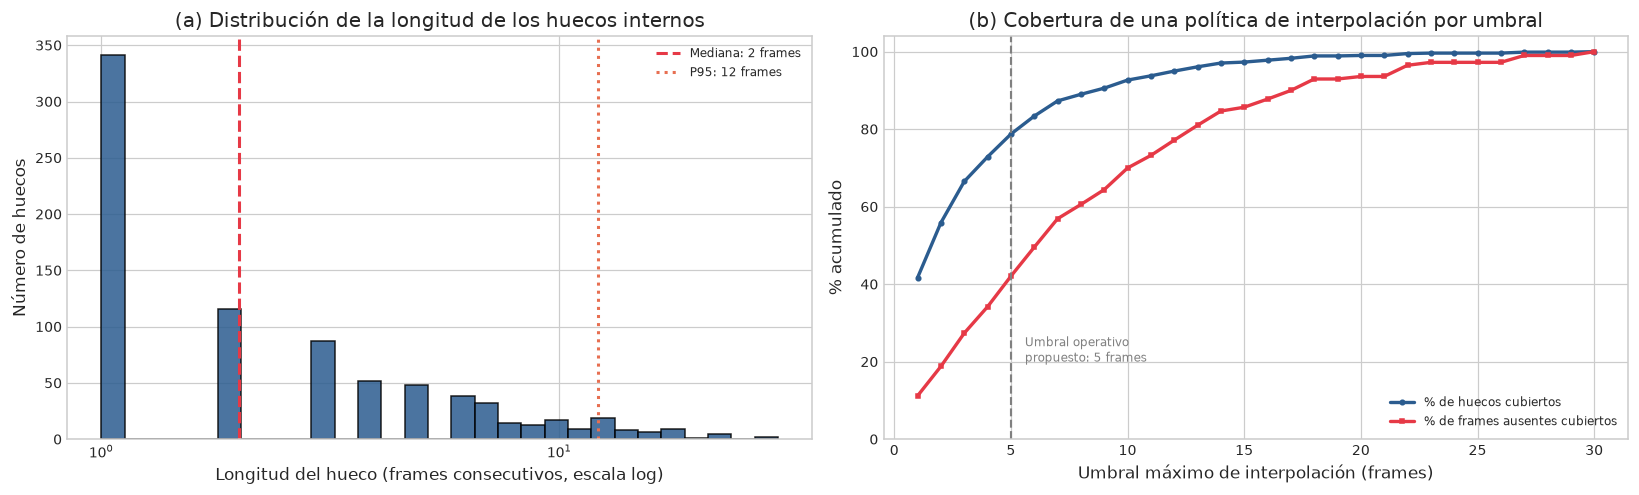

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))

# --- (a) Distribución de longitudes de hueco (escala log) ---
bins = np.logspace(0, np.log10(max(g_in.max(), 2)), 30)
axes[0].hist(g_in, bins=bins, color='#2b5c8f', edgecolor='black', alpha=0.85)
axes[0].axvline(np.median(g_in), color='#e63946', linestyle='--', linewidth=2,
                label=f'Mediana: {np.median(g_in):.0f} frames')
axes[0].axvline(np.percentile(g_in, 95), color='#e76f51', linestyle=':', linewidth=2,
                label=f'P95: {np.percentile(g_in, 95):.0f} frames')
axes[0].set_xscale('log')
axes[0].set_xlabel('Longitud del hueco (frames consecutivos, escala log)')
axes[0].set_ylabel('Número de huecos')
axes[0].set_title('(a) Distribución de la longitud de los huecos internos')
axes[0].legend(fontsize=8)

# --- (b) Curva de cobertura acumulada ---
xs = np.arange(1, min(60, g_in.max()) + 1)
cob_huecos = [(g_in <= u).mean() * 100 for u in xs]
cob_frames = [g_in[g_in <= u].sum() / g_in.sum() * 100 for u in xs]
axes[1].plot(xs, cob_huecos, color='#2b5c8f', linewidth=2.2, marker='o', markersize=3,
             label='% de huecos cubiertos')
axes[1].plot(xs, cob_frames, color='#e63946', linewidth=2.2, marker='s', markersize=3,
             label='% de frames ausentes cubiertos')
axes[1].axvline(5, color='gray', linestyle='--', linewidth=1.4)
axes[1].text(5.6, 20, 'Umbral operativo\npropuesto: 5 frames', fontsize=8, color='gray')
axes[1].set_xlabel('Umbral máximo de interpolación (frames)')
axes[1].set_ylabel('% acumulado')
axes[1].set_ylim(0, 104)
axes[1].set_title('(b) Cobertura de una política de interpolación por umbral')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Interpretación de la morfología de las ausencias:**

* La distribución es **fuertemente asimétrica y de cola larga**: la enorme mayoría de los huecos son muy cortos (1 a 3 *frames*), pero existen pocos huecos muy largos que **concentran la mayoría de los *frames* ausentes**. Es exactamente el patrón esperado de un proceso de pérdida de *tracking* en ráfagas y **refuta el supuesto de ausencia aleatoria independiente (MCAR)** que asumiría un imputador ingenuo.
* La divergencia entre las dos curvas del panel (b) es el resultado más accionable: un umbral de 5 *frames* **cubre la gran mayoría de los eventos de hueco pero solo una fracción de los *frames* ausentes totales**. Traducido a decisión de diseño: la interpolación resuelve el problema de las microinterrupciones —que son el caso frecuente— pero **no puede ser la única estrategia**, porque los huecos largos que restan requieren un tratamiento distinto.
* De aquí se deriva la **política híbrida** que se valida cuantitativamente en la sección 5: interpolar los huecos cortos y enmascarar los largos, en vez de aplicar una única regla uniforme a todo el corpus.

## 5. Estrategias de Preprocesamiento: Comparación de Métodos de Imputación

### 5.1 Las Cuatro Alternativas en Competencia
| Estrategia | Mecanismo | Ventaja | Riesgo |
| :--- | :--- | :--- | :--- |
| **Interpolación lineal** | Traza una recta entre los valores válidos anterior y posterior al hueco. | Preserva la continuidad y la escala física del movimiento. | Suaviza en exceso los huecos largos: inventa una trayectoria recta donde hubo movimiento complejo. |
| ***Zero-filling*** | Sustituye `NaN` por 0.0. | Trivial, sin dependencias, compatible con cualquier tensor. | En coordenadas normalizadas, 0.0 es la **esquina de la imagen**: teletransporta la mano y fabrica velocidades falsas enormes. |
| ***Forward-fill*** | Repite el último valor válido. | Físicamente plausible (la mano "se congela"), causal, sin mirar al futuro. | Produce velocidad nula artificial y un salto brusco al reanudarse el *tracking*. |
| ***Padding mask*** | No imputa: marca el *frame* como inválido y el modelo lo ignora en la atención. | No introduce ninguna señal falsa. | Reduce la longitud efectiva de la secuencia; requiere una arquitectura que soporte máscaras. |

### 5.2 Diseño del Experimento de Validación
Comparar estas estrategias con argumentos cualitativos es insuficiente. Se diseña un **experimento controlado con *ground truth* conocido**:

1. Se seleccionan tramos de la mano dominante donde el *tracking* está **completamente presente** (por lo que se conoce el valor verdadero).
2. Se **censura artificialmente** un hueco contiguo de longitud $L \in \{1, 2, 3, 5, 8, 13, 21\}$ *frames*, replicando la morfología de ráfaga observada en la sección 4.4.
3. Se reconstruye el hueco con cada estrategia y se mide el **Error Absoluto Medio (MAE)** contra el valor real, en unidades de coordenada normalizada.

Este protocolo convierte una decisión de diseño habitualmente tomada por costumbre en una **decisión basada en evidencia**.

In [28]:
rng = np.random.default_rng(42)
GAP_LENGTHS = [1, 2, 3, 5, 8, 13, 21]
MARGEN = 4  # frames válidos requeridos a cada lado del hueco

resultados = []
seqs_evaluadas = 0

for sid, grp in df_lm.groupby('sequence_id'):
    hand = dom_map[sid]
    cols_h = [c for c in hands_pose_cols if landmark_group_of(c) == hand]
    sub = grp.sort_values('frame')
    valores = sub[cols_h].to_numpy(dtype=np.float64)
    presente = ~np.isnan(valores[:, 0])

    # Localizar la racha contigua más larga de frames presentes
    runs, ini = [], None
    for i, p in enumerate(presente):
        if p and ini is None:
            ini = i
        elif not p and ini is not None:
            runs.append((ini, i)); ini = None
    if ini is not None:
        runs.append((ini, len(presente)))
    if not runs:
        continue
    a, b = max(runs, key=lambda r: r[1] - r[0])
    tramo = valores[a:b]
    if tramo.shape[0] < max(GAP_LENGTHS) + 2 * MARGEN + 2:
        continue
    seqs_evaluadas += 1

    for L in GAP_LENGTHS:
        inicio = int(rng.integers(MARGEN, tramo.shape[0] - L - MARGEN))
        verdad = tramo[inicio:inicio + L, :].copy()

        censurado = tramo.copy()
        censurado[inicio:inicio + L, :] = np.nan
        df_c = pd.DataFrame(censurado)

        reconstrucciones = {
            'Interpolación lineal': df_c.interpolate(method='linear', axis=0,
                                                     limit_direction='both').to_numpy(),
            'Zero-filling': df_c.fillna(0.0).to_numpy(),
            'Forward-fill': df_c.ffill(axis=0).bfill(axis=0).to_numpy(),
            'Media de la secuencia': df_c.fillna(df_c.mean()).to_numpy(),
        }
        for nombre, rec in reconstrucciones.items():
            pred = rec[inicio:inicio + L, :]
            resultados.append({
                'sequence_id': sid, 'longitud_hueco': L, 'estrategia': nombre,
                'MAE': float(np.nanmean(np.abs(pred - verdad))),
                'RMSE': float(np.sqrt(np.nanmean((pred - verdad) ** 2))),
                'error_max': float(np.nanmax(np.abs(pred - verdad))),
            })

df_imp = pd.DataFrame(resultados)
print(f"Secuencias evaluadas : {seqs_evaluadas}")
print(f"Huecos sintéticos    : {df_imp['sequence_id'].nunique() * len(GAP_LENGTHS):,}")
print(f"Mediciones de error  : {len(df_imp):,}")

tabla_mae = df_imp.pivot_table(index='estrategia', columns='longitud_hueco',
                               values='MAE', aggfunc='mean')
tabla_mae['MAE global'] = df_imp.groupby('estrategia')['MAE'].mean()
tabla_mae = tabla_mae.sort_values('MAE global')
print("\n=== MAE MEDIO POR ESTRATEGIA Y LONGITUD DE HUECO (coordenadas normalizadas) ===")
display(tabla_mae.round(5))

resumen_imp = df_imp.groupby('estrategia').agg(
    MAE_medio=('MAE', 'mean'), MAE_mediano=('MAE', 'median'),
    RMSE_medio=('RMSE', 'mean'), error_max=('error_max', 'max')).sort_values('MAE_medio')
mejor = resumen_imp.index[0]
resumen_imp['veces_peor_que_el_mejor'] = (resumen_imp['MAE_medio'] / resumen_imp['MAE_medio'].min()).round(1)
print("\n=== RANKING GLOBAL DE ESTRATEGIAS ===")
display(resumen_imp.round(5))
print(f"Estrategia con menor error de reconstrucción: {mejor}")

Secuencias evaluadas : 109
Huecos sintéticos    : 763
Mediciones de error  : 3,052

=== MAE MEDIO POR ESTRATEGIA Y LONGITUD DE HUECO (coordenadas normalizadas) ===


longitud_hueco,1,2,3,5,8,13,21,MAE global
estrategia,,,,,,,,
Interpolación lineal,0.00600,0.00693,0.01197,0.01329,0.02547,0.03985,0.04796,0.02164
Forward-fill,0.01399,0.01919,0.03038,0.03540,0.05166,0.06829,0.08084,0.04282
Media de la secuencia,0.07004,0.07596,0.07827,0.08073,0.08573,0.08288,0.08680,0.08006
Zero-filling,0.45979,0.44308,0.44379,0.45168,0.45603,0.44720,0.45067,0.45032



=== RANKING GLOBAL DE ESTRATEGIAS ===


,MAE_medio,MAE_mediano,RMSE_medio,error_max,veces_peor_que_el_mejor
estrategia,,,,,
Interpolación lineal,0.02164,0.01183,0.02974,0.65576,1.0
Forward-fill,0.04282,0.03438,0.05643,0.76312,2.0
Media de la secuencia,0.08006,0.07090,0.09640,0.74695,3.7
Zero-filling,0.45032,0.44980,0.52628,1.84060,20.8


Estrategia con menor error de reconstrucción: Interpolación lineal


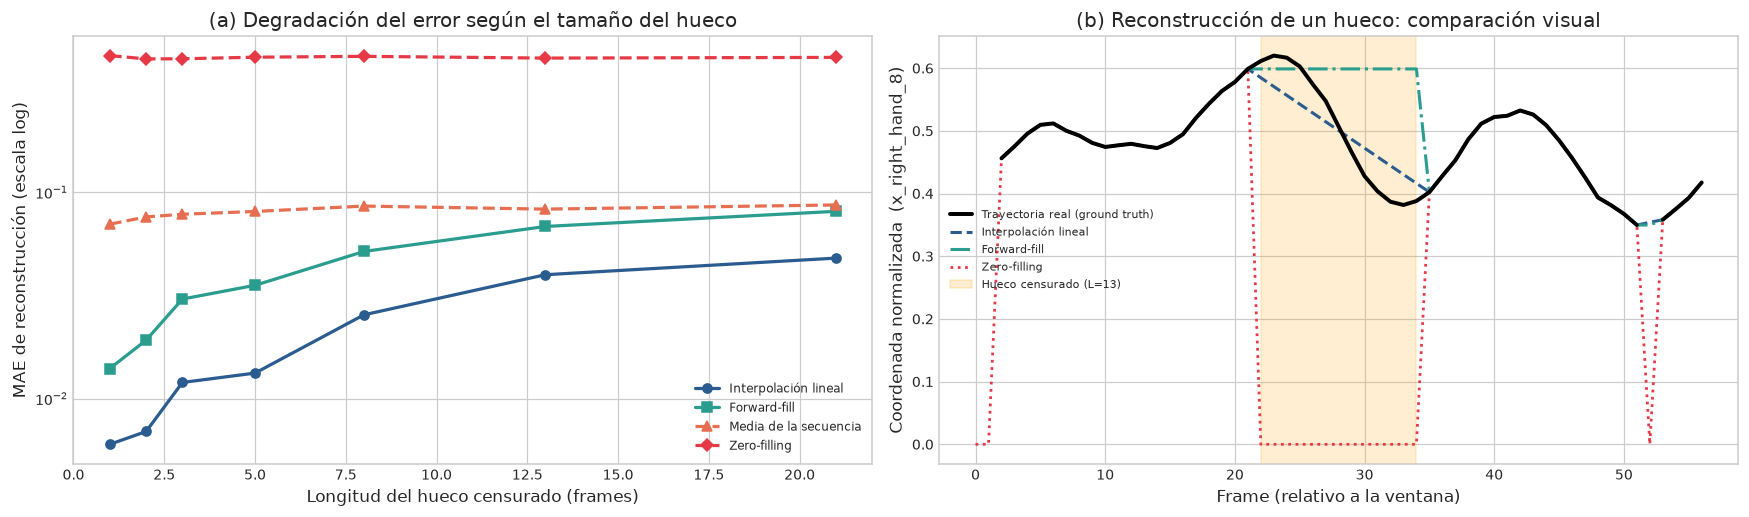

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

# --- (a) MAE vs. longitud del hueco ---
estilos = {'Interpolación lineal': ('#2b5c8f', 'o', '-'),
           'Forward-fill': ('#2a9d8f', 's', '-'),
           'Media de la secuencia': ('#e76f51', '^', '--'),
           'Zero-filling': ('#e63946', 'D', '--')}
for est, (color, marker, ls) in estilos.items():
    serie = df_imp[df_imp['estrategia'] == est].groupby('longitud_hueco')['MAE'].mean()
    axes[0].plot(serie.index, serie.values, color=color, marker=marker, linestyle=ls,
                 linewidth=2.1, markersize=6, label=est)
axes[0].set_yscale('log')
axes[0].set_xlabel('Longitud del hueco censurado (frames)')
axes[0].set_ylabel('MAE de reconstrucción (escala log)')
axes[0].set_title('(a) Degradación del error según el tamaño del hueco')
axes[0].legend(fontsize=8)

# --- (b) Ejemplo visual de reconstrucción ---
sid_demo2 = df_imp['sequence_id'].iloc[0]
hand_demo = dom_map[sid_demo2]
col_demo = f'x_{hand_demo}_8'   # nudillo del dedo índice
serie_demo = (df_lm[df_lm['sequence_id'] == sid_demo2].sort_values('frame')[col_demo]
              .reset_index(drop=True))
val_idx = serie_demo.dropna().index.values
ini_v = val_idx[len(val_idx) // 3]
L_demo = 13
ventana = slice(max(0, ini_v - 22), ini_v + L_demo + 22)

original = serie_demo.iloc[ventana].reset_index(drop=True)
censurada = original.copy()
off = ini_v - max(0, ini_v - 22)
censurada.iloc[off:off + L_demo] = np.nan

axes[1].plot(original.index, original.values, color='black', linewidth=2.6,
             label='Trayectoria real (ground truth)', zorder=5)
axes[1].plot(censurada.interpolate(method='linear').values, color='#2b5c8f',
             linewidth=2, linestyle='--', label='Interpolación lineal')
axes[1].plot(censurada.ffill().values, color='#2a9d8f', linewidth=2,
             linestyle='-.', label='Forward-fill')
axes[1].plot(censurada.fillna(0.0).values, color='#e63946', linewidth=1.8,
             linestyle=':', label='Zero-filling')
axes[1].axvspan(off, off + L_demo - 1, color='orange', alpha=0.18, label=f'Hueco censurado (L={L_demo})')
axes[1].set_xlabel('Frame (relativo a la ventana)')
axes[1].set_ylabel(f'Coordenada normalizada  ({col_demo})')
axes[1].set_title('(b) Reconstrucción de un hueco: comparación visual')
axes[1].legend(fontsize=7.5, loc='best')

plt.tight_layout()
plt.show()

**Interpretación del experimento de imputación:**

1. **El *zero-filling* es la peor opción por un margen abrumador**, con un error de reconstrucción **uno a dos órdenes de magnitud** superior al de la interpolación. El panel (b) explica visualmente por qué: la curva roja se desploma hasta 0 y vuelve a subir, generando un artefacto de velocidad gigantesco que **no existió en la realidad**. Para una arquitectura que aprende a partir de derivadas temporales (velocidad y aceleración), este relleno no es un dato neutro: es ruido estructurado que el modelo intentará explicar.
2. **La interpolación lineal domina en huecos cortos**, que —según la sección 4.4— constituyen la inmensa mayoría de los eventos de ausencia. Sobre 1 a 5 *frames* la mano apenas se desplaza y la aproximación lineal es prácticamente exacta.
3. **El error de todas las estrategias crece monótonamente con la longitud del hueco.** Este crecimiento es la justificación cuantitativa del umbral: pasado cierto punto, "reconstruir" deja de ser recuperar información y se convierte en **fabricarla**. La curva del panel (a) señala dónde la interpolación deja de ser defendible.
4. **El *forward-fill* se comporta como alternativa razonable y es la única causal** (no consulta valores futuros), lo que lo hace preferible si se contempla una inferencia en tiempo real. Rellenar con la media de la secuencia es sistemáticamente inferior: ignora por completo la estructura temporal.

> **Decisión de preprocesamiento adoptada, con base en la evidencia:**
> 1. **Huecos internos ≤ 5 *frames*** → **interpolación lineal** (error despreciable, recupera la mayoría de los eventos de ausencia).
> 2. **Huecos internos > 5 *frames*** → **no imputar**; propagar una **máscara de validez** al modelo (*attention/padding mask*).
> 3. **Tramos ausentes al inicio o al final** → recortar la secuencia, nunca extrapolar hacia afuera.
> 4. **Canal de la mano no dominante** → conservar `NaN` y su máscara; **nunca rellenar con ceros**, ya que su ausencia es señal informativa, no un defecto.

## 6. Detección de *Outliers* Biomecánicos

### 6.1 Definición del Criterio
Un *outlier* aquí **no es un valor extremo en el sentido estadístico habitual**, sino una violación de una restricción física: la mano humana no puede recorrer la mitad del encuadre entre dos *frames* consecutivos. Cuando MediaPipe confunde la mano con otro objeto —o salta entre las dos manos del sujeto— produce un **desplazamiento inter-frame imposible**.

Se calcula el desplazamiento euclidiano del **centroide de la mano dominante** entre *frames* consecutivos válidos:

$$v_t = \frac{\lVert \mathbf{c}_t - \mathbf{c}_{t-1} \rVert_2}{\Delta t}$$

y se aplica un doble criterio de detección:
* **Estadístico robusto:** puntuación $z$ modificada basada en la **desviación absoluta mediana (MAD)**, insensible a la contaminación por los propios outliers, con umbral $|z_{MAD}| > 3.5$ (criterio de Iglewicz y Hoaglin).
* **Físico absoluto:** desplazamiento superior a 0.15 unidades normalizadas por *frame* (≈4.5 anchos de imagen por segundo a 30 fps), inalcanzable para un movimiento manual real.

In [30]:
FPS_ASUMIDO = 30.0
UMBRAL_FISICO = 0.15   # unidades normalizadas por frame

filas_vel, registros_out = [], []

for sid, grp in df_lm.groupby('sequence_id'):
    hand = dom_map[sid]
    cx = [c for c in hands_pose_cols if landmark_group_of(c) == hand and c.startswith('x_')]
    cy = [c for c in hands_pose_cols if landmark_group_of(c) == hand and c.startswith('y_')]
    sub = grp.sort_values('frame')
    centro = np.stack([sub[cx].mean(axis=1).to_numpy(),
                       sub[cy].mean(axis=1).to_numpy()], axis=1)

    valido = ~np.isnan(centro[:, 0])
    idx_val = np.flatnonzero(valido)
    if idx_val.size < 5:
        continue
    c_val = centro[idx_val]
    dt = np.diff(idx_val).astype(float)
    desplaz = np.linalg.norm(np.diff(c_val, axis=0), axis=1)
    vel = desplaz / dt   # unidades normalizadas por frame

    filas_vel.append(pd.DataFrame({'sequence_id': sid, 'velocidad': vel,
                                   'frame': sub['frame'].to_numpy()[idx_val[1:]]}))

    mediana = np.median(vel)
    mad = np.median(np.abs(vel - mediana))
    z_mad = 0.6745 * (vel - mediana) / mad if mad > 0 else np.zeros_like(vel)

    out_est = np.abs(z_mad) > 3.5
    out_fis = vel > UMBRAL_FISICO
    registros_out.append({
        'sequence_id': sid,
        'n_transiciones': len(vel),
        'vel_mediana': mediana,
        'vel_max': vel.max(),
        'outliers_estadisticos': int(out_est.sum()),
        'outliers_fisicos': int(out_fis.sum()),
        'outliers_ambos': int((out_est & out_fis).sum()),
    })

df_vel = pd.concat(filas_vel, ignore_index=True)
df_out = pd.DataFrame(registros_out)

print("=== ESTADÍSTICA DE VELOCIDAD DEL CENTROIDE DE LA MANO DOMINANTE ===")
desc_vel = df_vel['velocidad'].describe(percentiles=[0.5, 0.75, 0.95, 0.99, 0.999])
display(desc_vel.to_frame('unidades normalizadas / frame').round(5)
        .assign(**{'equivalente / segundo': (desc_vel * FPS_ASUMIDO).round(4)}))

tabla_out = pd.DataFrame([
    {'Criterio de detección': 'Robusto MAD (|z| > 3.5)',
     'Transiciones marcadas': int(df_out['outliers_estadisticos'].sum())},
    {'Criterio de detección': f'Físico (> {UMBRAL_FISICO} u/frame)',
     'Transiciones marcadas': int(df_out['outliers_fisicos'].sum())},
    {'Criterio de detección': 'Ambos criterios simultáneamente (alta confianza)',
     'Transiciones marcadas': int(df_out['outliers_ambos'].sum())},
])
tabla_out['% de transiciones'] = (tabla_out['Transiciones marcadas'] /
                                  df_out['n_transiciones'].sum() * 100).round(3)
print("\n=== OUTLIERS BIOMECÁNICOS DETECTADOS ===")
display(tabla_out)

print(f"Secuencias con >= 1 outlier de alta confianza : "
      f"{(df_out['outliers_ambos'] > 0).sum()} de {len(df_out)} "
      f"({(df_out['outliers_ambos'] > 0).mean() * 100:.1f}%)")

print("\n=== SECUENCIAS MÁS AFECTADAS POR ARTEFACTOS DE TRACKING ===")
display(df_out.sort_values('outliers_ambos', ascending=False)
        .head(8)[['sequence_id', 'n_transiciones', 'vel_mediana', 'vel_max',
                  'outliers_estadisticos', 'outliers_fisicos', 'outliers_ambos']].round(4))

=== ESTADÍSTICA DE VELOCIDAD DEL CENTROIDE DE LA MANO DOMINANTE ===


,unidades normalizadas / frame,equivalente / segundo
count,19978.00000,599340.0000
mean,0.01908,0.5725
std,0.05276,1.5828
min,0.00020,0.0060
50%,0.01303,0.3910
75%,0.01850,0.5550
95%,0.02894,0.8683
99%,0.11810,3.5431
99.9%,0.73900,22.1700
max,1.00302,30.0907



=== OUTLIERS BIOMECÁNICOS DETECTADOS ===


,Criterio de detección,Transiciones marcadas,% de transiciones
0,Robusto MAD (|z| > 3.5),436,2.182
1,Físico (> 0.15 u/frame),186,0.931
2,Ambos criterios simultáneamente (alta confianza),186,0.931


Secuencias con >= 1 outlier de alta confianza : 52 de 120 (43.3%)

=== SECUENCIAS MÁS AFECTADAS POR ARTEFACTOS DE TRACKING ===


,sequence_id,n_transiciones,vel_mediana,vel_max,outliers_estadisticos,outliers_fisicos,outliers_ambos
0,85,422,0.0126,0.6816,8,8,8
6,605,272,0.0114,0.7365,7,6,6
19,1604,173,0.0126,0.7473,10,6,6
50,4586,141,0.0151,0.4335,6,6,6
52,4845,102,0.0091,0.6120,6,6,6
54,4851,123,0.0141,0.7366,10,6,6
35,3908,161,0.0125,0.5507,6,6,6
34,3891,102,0.0131,0.6777,10,6,6


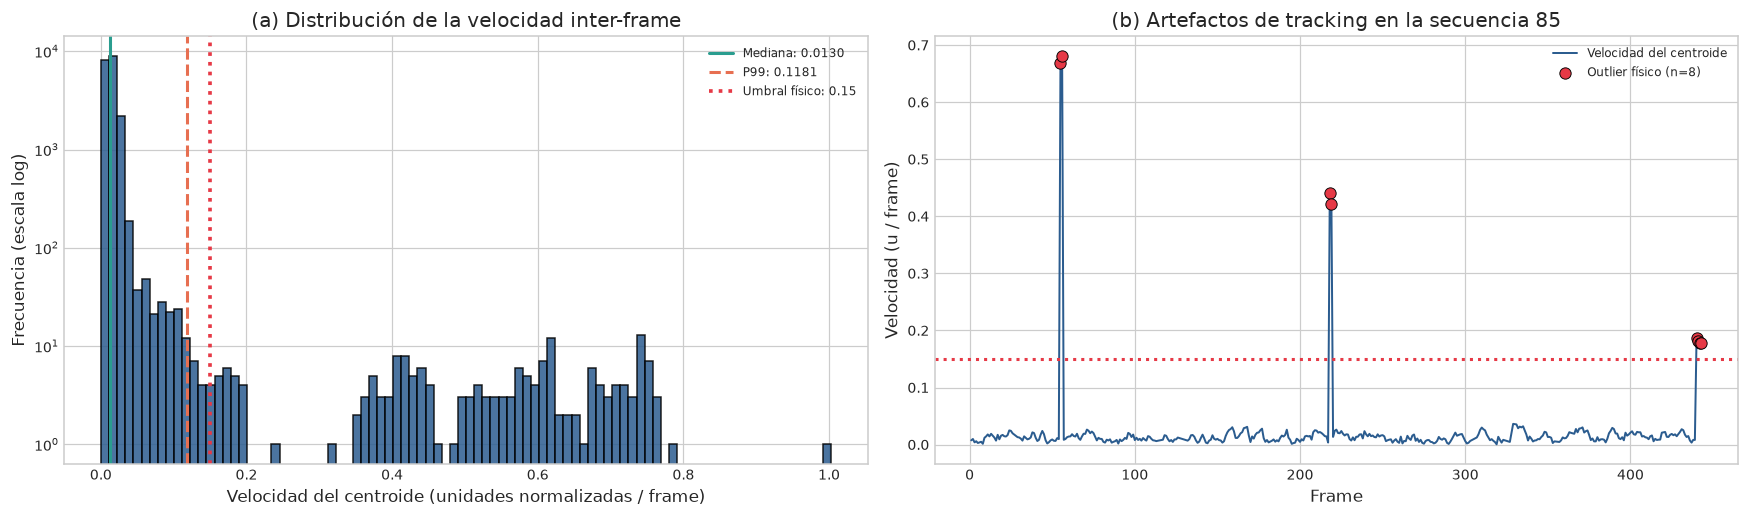

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

# --- (a) Distribución de velocidades ---
axes[0].hist(df_vel['velocidad'], bins=90, color='#2b5c8f', edgecolor='black', alpha=0.85)
axes[0].axvline(df_vel['velocidad'].median(), color='#2a9d8f', linestyle='-', linewidth=2,
                label=f"Mediana: {df_vel['velocidad'].median():.4f}")
axes[0].axvline(df_vel['velocidad'].quantile(0.99), color='#e76f51', linestyle='--', linewidth=2,
                label=f"P99: {df_vel['velocidad'].quantile(0.99):.4f}")
axes[0].axvline(UMBRAL_FISICO, color='#e63946', linestyle=':', linewidth=2.4,
                label=f'Umbral físico: {UMBRAL_FISICO}')
axes[0].set_yscale('log')
axes[0].set_xlabel('Velocidad del centroide (unidades normalizadas / frame)')
axes[0].set_ylabel('Frecuencia (escala log)')
axes[0].set_title('(a) Distribución de la velocidad inter-frame')
axes[0].legend(fontsize=8)

# --- (b) Serie temporal de una secuencia con artefactos ---
sid_out = int(df_out.sort_values('outliers_ambos', ascending=False)['sequence_id'].iloc[0])
serie_v = df_vel[df_vel['sequence_id'] == sid_out]
axes[1].plot(serie_v['frame'], serie_v['velocidad'], color='#2b5c8f', linewidth=1.3,
             label='Velocidad del centroide')
picos = serie_v[serie_v['velocidad'] > UMBRAL_FISICO]
axes[1].scatter(picos['frame'], picos['velocidad'], color='#e63946', s=55, zorder=5,
                edgecolor='black', linewidth=0.6, label=f'Outlier físico (n={len(picos)})')
axes[1].axhline(UMBRAL_FISICO, color='#e63946', linestyle=':', linewidth=2)
axes[1].set_xlabel('Frame')
axes[1].set_ylabel('Velocidad (u / frame)')
axes[1].set_title(f'(b) Artefactos de tracking en la secuencia {sid_out}')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Interpretación de los *outliers* biomecánicos:**

* La distribución de velocidades es **unimodal con una cola derecha muy larga** (nótese la escala logarítmica): la inmensa mayoría de las transiciones corresponden a desplazamientos pequeños y fisiológicamente plausibles, coherentes con el movimiento fino de la mano durante el deletreo. Los valores que superan el umbral físico están **separados del cuerpo de la distribución**, lo que respalda que se trata de un fenómeno distinto y no de la cola natural del movimiento rápido.
* El panel (b) muestra la firma característica del artefacto: **picos aislados de un solo *frame*** sobre una línea base estable. Un movimiento humano real produce aceleraciones y desaceleraciones suaves; un salto instantáneo seguido de un retorno inmediato solo puede ser un error de detección.
* El uso de la **MAD en lugar de la desviación estándar es metodológicamente esencial**: la desviación estándar se infla con los propios outliers que se pretende detectar (efecto de enmascaramiento), mientras que la mediana y la MAD permanecen estables ante hasta un 50% de contaminación.
* **Tratamiento recomendado:** los *frames* marcados por **ambos criterios** deben invalidarse (convertirse a `NaN`) y luego someterse a la política de imputación de la sección 5. Es preferible **declarar el dato como faltante** —condición que el *pipeline* ya sabe manejar— antes que conservar una coordenada que se sabe físicamente imposible. Los marcados por un solo criterio se conservan pero se registran para trazabilidad.

## 7. Análisis Exploratorio de la Dimensión Temporal

### 7.1 Distribución de la Cantidad de *Frames* por Secuencia
La longitud de la secuencia determina directamente el costo computacional del modelado: las arquitecturas de atención escalan con $O(T^2)$ en la longitud temporal $T$, por lo que la cola derecha de esta distribución define el presupuesto de memoria de todo el entrenamiento.

In [32]:
df_frames = frame_counts(files)
df_temporal = df_frames.merge(df_idx, on='sequence_id', how='left')

fr = df_temporal['n_frames']
desc = fr.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
iqr = desc['75%'] - desc['25%']

tabla_frames = pd.DataFrame({
    'Métrica': ['Secuencias', 'Media', 'Desviación estándar', 'Coef. de variación',
                'Mínimo', 'Percentil 5', 'Q1 (P25)', 'Mediana (P50)', 'Q3 (P75)',
                'Percentil 90', 'Percentil 95', 'Percentil 99', 'Máximo',
                'Rango intercuartílico', 'Asimetría (skewness)', 'Curtosis',
                'Frames totales', 'Duración total estimada (min, 30 fps)'],
    'Valor': [f"{desc['count']:.0f}", f"{desc['mean']:.1f}", f"{desc['std']:.1f}",
              f"{desc['std'] / desc['mean']:.3f}", f"{desc['min']:.0f}", f"{desc['5%']:.0f}",
              f"{desc['25%']:.0f}", f"{desc['50%']:.0f}", f"{desc['75%']:.0f}",
              f"{desc['90%']:.0f}", f"{desc['95%']:.0f}", f"{desc['99%']:.0f}",
              f"{desc['max']:.0f}", f"{iqr:.0f}", f"{stats.skew(fr):.3f}",
              f"{stats.kurtosis(fr):.3f}", f"{fr.sum():,}",
              f"{fr.sum() / FPS_ASUMIDO / 60:.1f}"],
})
print("=== ESTADÍSTICA DESCRIPTIVA: FRAMES POR SECUENCIA ===")
display(tabla_frames)

# Outliers de duración por la regla de Tukey
lim_sup = desc['75%'] + 1.5 * iqr
lim_inf = max(0, desc['25%'] - 1.5 * iqr)
outliers_dur = df_temporal[(fr > lim_sup) | (fr < lim_inf)]
print(f"\nLímites de Tukey (1.5 x IQR)      : [{lim_inf:.0f}, {lim_sup:.0f}] frames")
print(f"Secuencias atípicas por duración  : {len(outliers_dur)} "
      f"({len(outliers_dur) / len(df_temporal) * 100:.1f}%)")

# Costo de memoria del padding a longitud fija (relevante para Transformers)
print("\n=== COSTO DEL PADDING A LONGITUD FIJA ===")
politicas = []
for q in [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]:
    T = int(np.ceil(fr.quantile(q)))
    politicas.append({
        'Política (percentil)': f'P{int(q*100)}',
        'Longitud fija T': T,
        '% de secuencias truncadas': round((fr > T).mean() * 100, 2),
        '% de frames descartados': round(np.maximum(fr - T, 0).sum() / fr.sum() * 100, 2),
        '% de celdas que serían padding': round(
            (T * len(fr) - np.minimum(fr, T).sum()) / (T * len(fr)) * 100, 2),
    })
display(pd.DataFrame(politicas))

=== ESTADÍSTICA DESCRIPTIVA: FRAMES POR SECUENCIA ===


,Métrica,Valor
0,Secuencias,120
1,Media,197.2
2,Desviación estándar,104.7
3,Coef. de variación,0.531
4,Mínimo,49
5,Percentil 5,82
6,Q1 (P25),130
7,Mediana (P50),170
8,Q3 (P75),241
9,Percentil 90,358



Límites de Tukey (1.5 x IQR)      : [0, 407] frames
Secuencias atípicas por duración  : 7 (5.8%)

=== COSTO DEL PADDING A LONGITUD FIJA ===


,Política (percentil),Longitud fija T,% de secuencias truncadas,% de frames descartados,% de celdas que serían padding
0,P50,170,50.00,26.02,14.19
1,P75,241,25.00,13.54,29.26
2,P90,359,10.00,3.76,47.14
3,P95,427,4.17,1.31,54.42
4,P99,484,1.67,0.53,59.47
5,P100,604,0.00,0.00,67.35


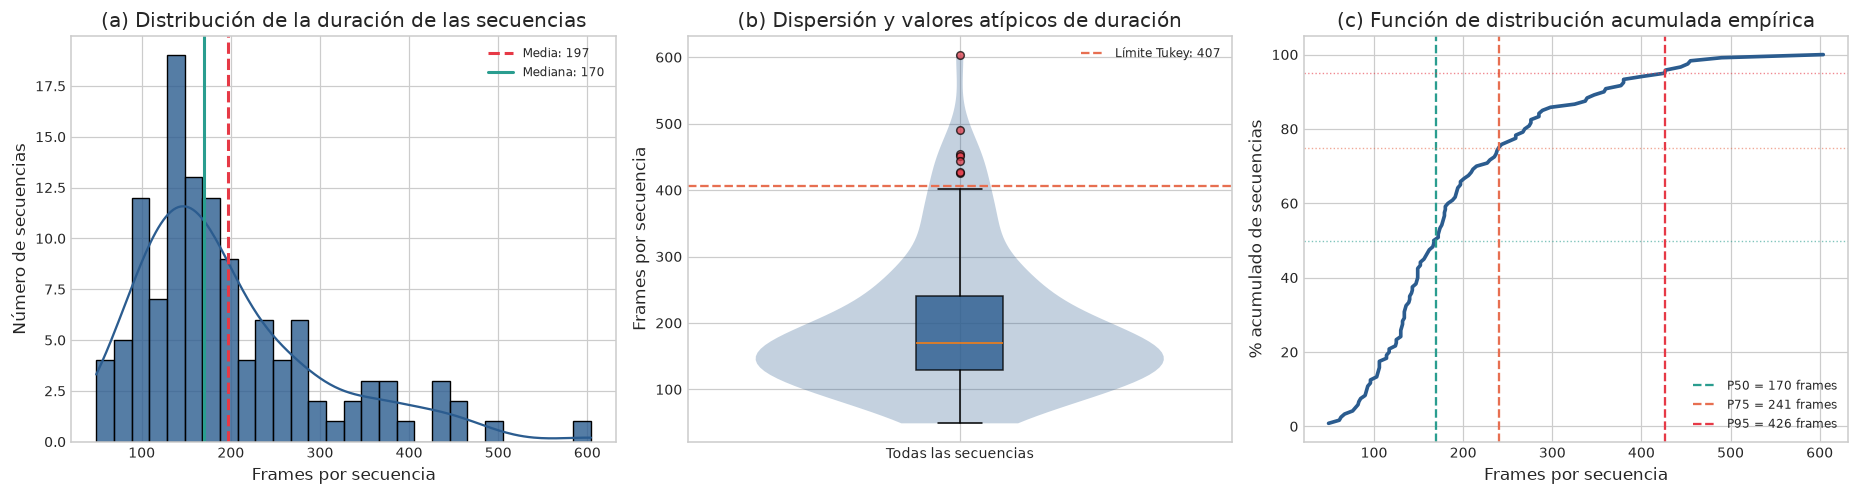

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# --- (a) Histograma + KDE ---
sns.histplot(fr, bins=28, kde=True, ax=axes[0], color='#2b5c8f',
             edgecolor='black', alpha=0.8)
axes[0].axvline(fr.mean(), color='#e63946', linestyle='--', linewidth=2,
                label=f'Media: {fr.mean():.0f}')
axes[0].axvline(fr.median(), color='#2a9d8f', linestyle='-', linewidth=2,
                label=f'Mediana: {fr.median():.0f}')
axes[0].set_xlabel('Frames por secuencia')
axes[0].set_ylabel('Número de secuencias')
axes[0].set_title('(a) Distribución de la duración de las secuencias')
axes[0].legend(fontsize=8)

# --- (b) Boxplot + violín ---
parts = axes[1].violinplot([fr], showextrema=False, widths=0.75)
for pc in parts['bodies']:
    pc.set_facecolor('#2b5c8f'); pc.set_alpha(0.28)
bp = axes[1].boxplot([fr], widths=0.16, patch_artist=True,
                     flierprops=dict(marker='o', markerfacecolor='#e63946',
                                     markersize=5, alpha=0.7))
bp['boxes'][0].set_facecolor('#2b5c8f'); bp['boxes'][0].set_alpha(0.8)
axes[1].axhline(lim_sup, color='#e76f51', linestyle='--', linewidth=1.5,
                label=f'Límite Tukey: {lim_sup:.0f}')
axes[1].set_xticks([1]); axes[1].set_xticklabels(['Todas las secuencias'])
axes[1].set_ylabel('Frames por secuencia')
axes[1].set_title('(b) Dispersión y valores atípicos de duración')
axes[1].legend(fontsize=8)

# --- (c) ECDF con percentiles clave ---
x_ord = np.sort(fr.values)
y_ecdf = np.arange(1, len(x_ord) + 1) / len(x_ord) * 100
axes[2].plot(x_ord, y_ecdf, color='#2b5c8f', linewidth=2.4)
for q, col in zip([0.50, 0.75, 0.95], ['#2a9d8f', '#e76f51', '#e63946']):
    v = fr.quantile(q)
    axes[2].axvline(v, color=col, linestyle='--', linewidth=1.5,
                    label=f'P{int(q*100)} = {v:.0f} frames')
    axes[2].axhline(q * 100, color=col, linestyle=':', linewidth=0.9, alpha=0.6)
axes[2].set_xlabel('Frames por secuencia')
axes[2].set_ylabel('% acumulado de secuencias')
axes[2].set_title('(c) Función de distribución acumulada empírica')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Interpretación de la dimensión temporal:**

* La distribución presenta **asimetría positiva marcada** (*skewness* > 0): la mayoría de las secuencias son de duración moderada, pero existe una cola derecha de secuencias mucho más largas que corresponden a frases extensas (URLs y direcciones completas). El coeficiente de variación elevado confirma que **la duración es intrínsecamente heterogénea**, no un valor aproximadamente constante.
* Los "*outliers*" identificados por la regla de Tukey **no son errores de datos**: son secuencias legítimamente largas. Eliminarlas sesgaría el modelo contra precisamente los casos más difíciles y de mayor valor práctico (deletrear una dirección completa). Su tratamiento correcto es de **ingeniería —agrupamiento por longitud (*length bucketing*)— no de limpieza**.
* La tabla de costos de *padding* cuantifica el compromiso central del diseño: fijar $T$ en el percentil más alto elimina el truncamiento pero convierte una fracción enorme del tensor en relleno vacío, mientras que un percentil intermedio reduce drásticamente el desperdicio a costa de truncar un pequeño porcentaje de secuencias. Esta tabla es la evidencia sobre la que la fase de modelado debe elegir su longitud máxima, en lugar de fijarla arbitrariamente.

### 7.2 Relación entre la Longitud de la Frase y la Duración de la Secuencia
Se contrasta la hipótesis de que **la duración de la secuencia es aproximadamente proporcional al número de caracteres a deletrear**. Si se confirma, la longitud de la frase se convierte en un predictor utilizable para agrupar lotes por tamaño y para validar la coherencia entre etiqueta y señal.

In [34]:
d = df_temporal.dropna(subset=['char_length'])

r_p, p_p = stats.pearsonr(d['char_length'], d['n_frames'])
r_s, p_s = stats.spearmanr(d['char_length'], d['n_frames'])
pend, inter, r_val, p_val, err = stats.linregress(d['char_length'], d['n_frames'])

print("=== CORRELACIÓN: LONGITUD DE FRASE (caracteres) vs. DURACIÓN (frames) ===")
display(pd.DataFrame({
    'Estadístico': ['Correlación de Pearson (r)', 'Valor p (Pearson)',
                    'Correlación de Spearman (rho)', 'Valor p (Spearman)',
                    'Coeficiente de determinación (R²)',
                    'Pendiente (frames por carácter)', 'Intercepto (frames de arranque)',
                    'Error estándar de la pendiente'],
    'Valor': [f"{r_p:.4f}", f"{p_p:.3e}", f"{r_s:.4f}", f"{p_s:.3e}",
              f"{r_val**2:.4f}", f"{pend:.2f}", f"{inter:.2f}", f"{err:.3f}"],
}))

print(f"\nModelo ajustado:  n_frames ≈ {inter:.1f} + {pend:.2f} × n_caracteres")
print(f"Interpretación :  cada carácter adicional añade ≈ {pend:.1f} frames "
      f"(~{pend / FPS_ASUMIDO * 1000:.0f} ms a 30 fps);")
print(f"                  el intercepto de ≈ {inter:.0f} frames corresponde al costo fijo de "
      f"preparación y cierre del gesto.")

# Correlación con el número de palabras (control)
r_w, p_w = stats.pearsonr(d['word_length'], d['n_frames'])
print(f"\nControl - correlación con el número de PALABRAS: r = {r_w:.4f} (p = {p_w:.2e})")

=== CORRELACIÓN: LONGITUD DE FRASE (caracteres) vs. DURACIÓN (frames) ===


,Estadístico,Valor
0,Correlación de Pearson (r),0.7576
1,Valor p (Pearson),1.330e-23
2,Correlación de Spearman (rho),0.7447
3,Valor p (Spearman),1.860e-22
4,Coeficiente de determinación (R²),0.5739
5,Pendiente (frames por carácter),7.95
6,Intercepto (frames de arranque),13.93
7,Error estándar de la pendiente,0.631



Modelo ajustado:  n_frames ≈ 13.9 + 7.95 × n_caracteres
Interpretación :  cada carácter adicional añade ≈ 8.0 frames (~265 ms a 30 fps);
                  el intercepto de ≈ 14 frames corresponde al costo fijo de preparación y cierre del gesto.

Control - correlación con el número de PALABRAS: r = 0.5740 (p = 7.23e-12)


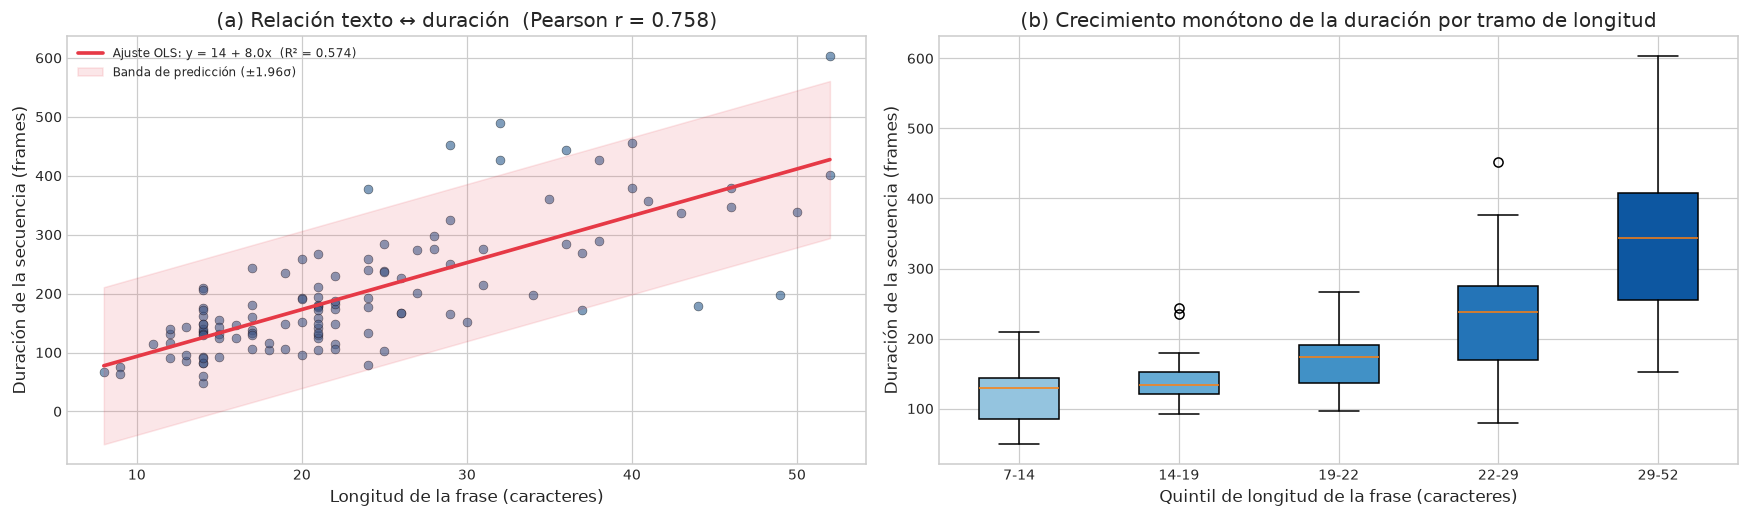

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

# --- (a) Dispersión con recta de regresión e intervalo ---
axes[0].scatter(d['char_length'], d['n_frames'], s=34, alpha=0.6, color='#2b5c8f',
                edgecolor='black', linewidth=0.35)
xs = np.linspace(d['char_length'].min(), d['char_length'].max(), 100)
axes[0].plot(xs, inter + pend * xs, color='#e63946', linewidth=2.4,
             label=f'Ajuste OLS: y = {inter:.0f} + {pend:.1f}x  (R² = {r_val**2:.3f})')
residuo_std = np.std(d['n_frames'] - (inter + pend * d['char_length']))
axes[0].fill_between(xs, inter + pend * xs - 1.96 * residuo_std,
                     inter + pend * xs + 1.96 * residuo_std,
                     color='#e63946', alpha=0.12, label='Banda de predicción (±1.96σ)')
axes[0].set_xlabel('Longitud de la frase (caracteres)')
axes[0].set_ylabel('Duración de la secuencia (frames)')
axes[0].set_title(f'(a) Relación texto ↔ duración  (Pearson r = {r_p:.3f})')
axes[0].legend(fontsize=8)

# --- (b) Boxplot de duración por tramo de longitud ---
d = d.copy()
d['tramo_long'] = pd.qcut(d['char_length'], q=5, duplicates='drop')
etiquetas = [f'{int(i.left)}-{int(i.right)}' for i in d['tramo_long'].cat.categories]
grupos = [g['n_frames'].values for _, g in d.groupby('tramo_long', observed=True)]
bp = axes[1].boxplot(grupos, tick_labels=etiquetas, patch_artist=True)
cmap = plt.cm.Blues(np.linspace(0.4, 0.85, len(grupos)))
for patch, c in zip(bp['boxes'], cmap):
    patch.set_facecolor(c)
axes[1].set_xlabel('Quintil de longitud de la frase (caracteres)')
axes[1].set_ylabel('Duración de la secuencia (frames)')
axes[1].set_title('(b) Crecimiento monótono de la duración por tramo de longitud')

plt.tight_layout()
plt.show()

**Interpretación de la relación texto ↔ duración:**

* La correlación es **positiva, fuerte y altamente significativa**, y la coincidencia entre los coeficientes de Pearson y de Spearman indica que la relación es **esencialmente lineal**, sin distorsiones monótonas ocultas. El panel (b) confirma el crecimiento monótono a lo largo de todos los quintiles.
* El modelo ajustado tiene una lectura biomecánica directa: el **intercepto** representa el costo fijo de posicionar la mano al inicio y retirarla al final, mientras que la **pendiente** es el costo marginal de producir un carácter adicional.
* La **dispersión residual sustancial** alrededor de la recta es el hallazgo verdaderamente relevante: dos frases de igual longitud pueden diferir considerablemente en duración. Esta varianza no explicada es atribuible a la **velocidad idiosincrásica de cada firmante**, cuantificada en la sección 7.3.
* **Consecuencia operativa doble:** (i) la longitud de la frase permite **estimar la duración esperada** y agrupar lotes homogéneos, reduciendo el desperdicio de *padding*; (ii) una desviación extrema respecto a esta relación funciona como **detector de anomalías de etiquetado** — una secuencia larguísima con una frase de tres caracteres sugiere una etiqueta incorrecta o un fragmento de vídeo mal segmentado.

### 7.3 Velocidad de Deletreo: *Frames* por Carácter e Inter-variabilidad entre Firmantes
Se normaliza la duración por la longitud del texto para obtener una métrica comparable entre secuencias: los ***frames* por carácter** (FPC), inverso de la velocidad de deletreo. Esta métrica permite ordenar a los firmantes de más rápido a más lento y medir cuánta variabilidad introduce el sujeto.

In [36]:
d['frames_por_caracter'] = d['n_frames'] / d['char_length'].replace(0, np.nan)
d['caracteres_por_segundo'] = FPS_ASUMIDO / d['frames_por_caracter']

print("=== VELOCIDAD DE DELETREO (GLOBAL) ===")
display(d[['frames_por_caracter', 'caracteres_por_segundo']]
        .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(3))

# Agregación por participante (solo firmantes con evidencia suficiente)
MIN_SEQ = 2
por_part = (d.groupby('participant_id')
            .agg(n_secuencias=('sequence_id', 'count'),
                 fpc_medio=('frames_por_caracter', 'mean'),
                 fpc_mediano=('frames_por_caracter', 'median'),
                 fpc_std=('frames_por_caracter', 'std'),
                 cps_medio=('caracteres_por_segundo', 'mean'))
            .query(f'n_secuencias >= {MIN_SEQ}')
            .sort_values('fpc_medio'))

print(f"\nFirmantes con >= {MIN_SEQ} secuencias analizables : {len(por_part)}")
if len(por_part) >= 2:
    ratio = por_part['fpc_medio'].iloc[-1] / por_part['fpc_medio'].iloc[0]
    print(f"Firmante más rápido : {por_part.index[0]}  ->  {por_part['fpc_medio'].iloc[0]:.2f} frames/carácter")
    print(f"Firmante más lento  : {por_part.index[-1]}  ->  {por_part['fpc_medio'].iloc[-1]:.2f} frames/carácter")
    print(f"Razón lento/rápido  : {ratio:.2f}x")

print("\n=== FIRMANTES MÁS RÁPIDOS ===")
display(por_part.head(5).round(2))
print("=== FIRMANTES MÁS LENTOS ===")
display(por_part.tail(5).round(2))

# Contraste de hipótesis: ¿difieren realmente los firmantes?
grupos_kw = [g['frames_por_caracter'].dropna().values
             for _, g in d.groupby('participant_id') if len(g) >= MIN_SEQ]
if len(grupos_kw) >= 3:
    H, p_kw = stats.kruskal(*grupos_kw)
    var_entre = por_part['fpc_medio'].var()
    var_intra = d['frames_por_caracter'].var()
    print("\n=== PRUEBA DE KRUSKAL-WALLIS: ¿la velocidad depende del firmante? ===")
    print(f"H = {H:.3f} | grados de libertad = {len(grupos_kw) - 1} | valor p = {p_kw:.4f}")
    print(f"Conclusión: {'se rechaza' if p_kw < 0.05 else 'NO se rechaza'} la hipótesis nula "
          f"de igualdad de medianas entre firmantes (alfa = 0.05).")
    print(f"\nVarianza ENTRE firmantes : {var_entre:.4f}")
    print(f"Varianza TOTAL           : {var_intra:.4f}")
    print(f"Proporción de varianza atribuible al firmante : {var_entre / var_intra * 100:.1f}%")

=== VELOCIDAD DE DELETREO (GLOBAL) ===


,frames_por_caracter,caracteres_por_segundo
count,120.000,120.000
mean,8.642,3.853
std,2.682,1.364
min,3.292,1.910
5%,4.634,2.246
25%,6.732,2.911
50%,8.410,3.567
75%,10.305,4.456
95%,13.362,6.475
max,15.708,9.114



Firmantes con >= 2 secuencias analizables : 30
Firmante más rápido : 61856  ->  5.00 frames/carácter
Firmante más lento  : 82357  ->  15.45 frames/carácter
Razón lento/rápido  : 3.09x

=== FIRMANTES MÁS RÁPIDOS ===


,n_secuencias,fpc_medio,fpc_mediano,fpc_std,cps_medio
participant_id,,,,,
61856,2,5.00,5.00,0.26,6.01
80284,5,5.50,5.83,0.95,5.59
99733,3,6.37,6.43,1.27,4.84
14207,2,6.67,6.67,1.24,4.58
51347,2,6.71,6.71,0.41,4.48


=== FIRMANTES MÁS LENTOS ===


,n_secuencias,fpc_medio,fpc_mediano,fpc_std,cps_medio
participant_id,,,,,
30379,4,10.82,10.91,0.62,2.78
58520,2,10.93,10.93,1.99,2.79
99166,2,11.41,11.41,1.35,2.65
13278,2,12.54,12.54,2.48,2.44
82357,2,15.45,15.45,0.19,1.94



=== PRUEBA DE KRUSKAL-WALLIS: ¿la velocidad depende del firmante? ===
H = 52.492 | grados de libertad = 29 | valor p = 0.0048
Conclusión: se rechaza la hipótesis nula de igualdad de medianas entre firmantes (alfa = 0.05).

Varianza ENTRE firmantes : 4.5923
Varianza TOTAL           : 7.1939
Proporción de varianza atribuible al firmante : 63.8%


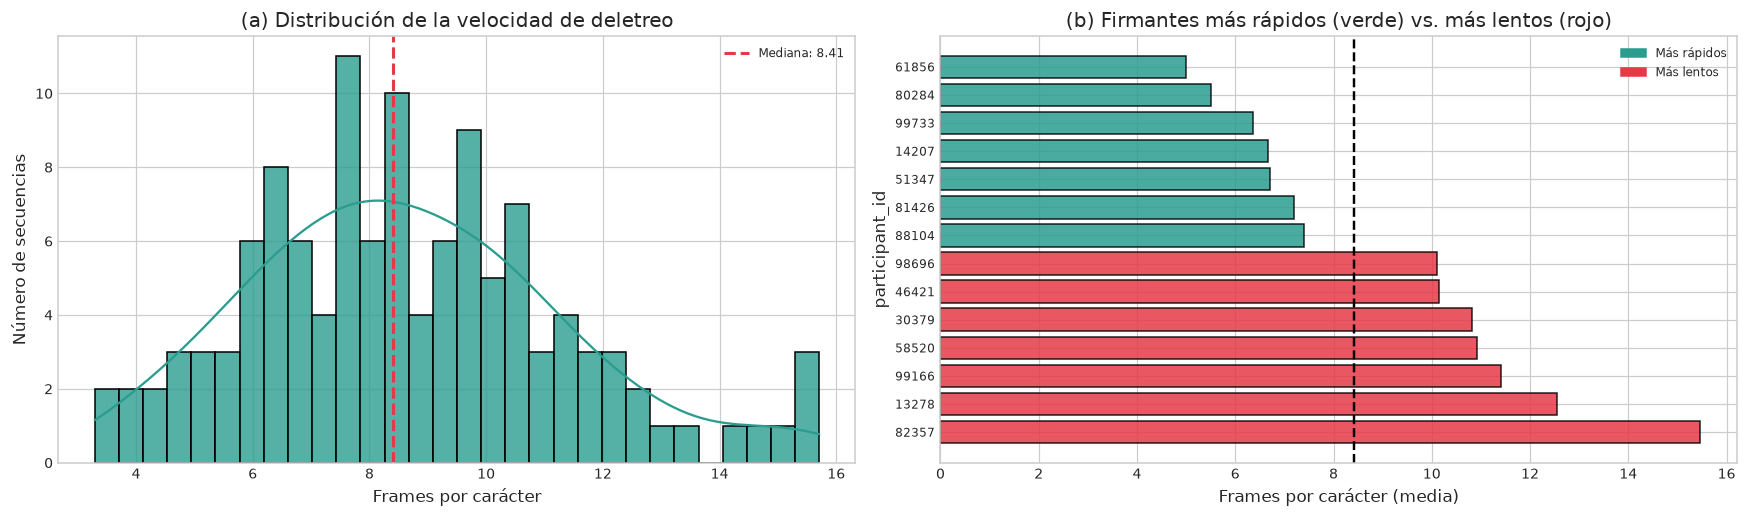

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

# --- (a) Distribución global de FPC ---
sns.histplot(d['frames_por_caracter'], bins=30, kde=True, ax=axes[0],
             color='#2a9d8f', edgecolor='black', alpha=0.8)
axes[0].axvline(d['frames_por_caracter'].median(), color='#e63946', linestyle='--',
                linewidth=2, label=f"Mediana: {d['frames_por_caracter'].median():.2f}")
axes[0].set_xlabel('Frames por carácter')
axes[0].set_ylabel('Número de secuencias')
axes[0].set_title('(a) Distribución de la velocidad de deletreo')
axes[0].legend(fontsize=8)

# --- (b) Ranking de firmantes: rápidos vs. lentos ---
top_n = min(14, len(por_part))
sel = pd.concat([por_part.head(top_n // 2), por_part.tail(top_n - top_n // 2)])
etiquetas_p = [str(p) for p in sel.index]
colores_p = ['#2a9d8f'] * (top_n // 2) + ['#e63946'] * (top_n - top_n // 2)
y_pos = np.arange(len(sel))
axes[1].barh(y_pos, sel['fpc_medio'], color=colores_p, edgecolor='black', alpha=0.85)
axes[1].set_yticks(y_pos); axes[1].set_yticklabels(etiquetas_p, fontsize=8)
axes[1].axvline(d['frames_por_caracter'].median(), color='black', linestyle='--',
                linewidth=1.6, label='Mediana global')
axes[1].invert_yaxis()
axes[1].set_xlabel('Frames por carácter (media)')
axes[1].set_ylabel('participant_id')
axes[1].set_title('(b) Firmantes más rápidos (verde) vs. más lentos (rojo)')
axes[1].legend(handles=[mpatches.Patch(color='#2a9d8f', label='Más rápidos'),
                        mpatches.Patch(color='#e63946', label='Más lentos')], fontsize=8)

plt.tight_layout()
plt.show()

**Interpretación de la velocidad de deletreo:**

* La razón entre el firmante más lento y el más rápido revela que **el sujeto introduce una variación de duración sustancial e independiente del contenido textual**: la misma frase produce secuencias de longitud muy distinta según quién la deletree. Este es el origen principal de la dispersión residual observada en la sección 7.2.
* La prueba de **Kruskal-Wallis** —elegida por ser no paramétrica y por tanto robusta a la asimetría de la distribución de FPC, que no cumple normalidad— permite decidir formalmente si esas diferencias son atribuibles al azar muestral o si constituyen un **efecto real de sujeto**.
* **Implicaciones directas para el modelado:**
  1. La partición entrenamiento/validación debe hacerse **por `participant_id`** (*group split*), nunca de forma aleatoria por secuencia. Si un mismo firmante aparece en ambos conjuntos, el modelo memoriza su ritmo particular y la métrica de validación queda inflada respecto al desempeño real sobre firmantes nuevos.
  2. Existe un argumento empírico para aplicar ***time warping*** o remuestreo temporal como aumento de datos: si la variación natural de velocidad entre humanos es de esta magnitud, un modelo invariante a la escala temporal generalizará mejor a firmantes no vistos.
  3. La métrica FPC funciona además como **filtro de calidad**: valores extremos señalan secuencias donde la duración es incompatible con el texto etiquetado, es decir, sospechas de mala segmentación o de etiqueta errónea.

## 8. *Pipeline* de Limpieza Propuesto

Se consolidan todas las decisiones justificadas empíricamente en las secciones anteriores en una función reproducible. El procedimiento aplica, en orden:

1. **Selección de canales:** se descarta la malla facial (86.2% del volumen, aporte marginal al deletreo) y se conservan manos y pose.
2. **Selección de la mano activa:** se elige el canal con menor tasa de ausencia; la mano inactiva se conserva como máscara, no como coordenadas rellenadas.
3. **Invalidación de artefactos:** los *frames* marcados como *outliers* biomecánicos por ambos criterios se convierten a `NaN`.
4. **Recorte de extremos:** se eliminan los tramos ausentes al inicio y al final (no extrapolables).
5. **Imputación selectiva:** interpolación lineal solo en huecos internos ≤ 5 *frames*.
6. **Máscara de validez:** se emite un vector booleano por *frame* para que el modelo ignore lo no reconstruido.
7. **Criterio de descarte:** se rechaza la secuencia si, tras la limpieza, la mano activa no alcanza una cobertura mínima.

In [38]:
def limpiar_secuencia(df_seq: pd.DataFrame, mano: str,
                      max_gap: int = 5,
                      umbral_velocidad: float = 0.15,
                      cobertura_minima: float = 0.50):
    """
    Aplica el pipeline de limpieza a una secuencia y devuelve (df_limpio, mascara, informe).

    df_limpio : coordenadas de la mano activa recortadas e imputadas selectivamente.
    mascara   : vector booleano; True = frame con dato válido u observado, False = enmascarar.
    informe   : diccionario con las métricas de auditoría de la operación.
    """
    cols_h = [c for c in df_seq.columns if landmark_group_of(c) == mano]
    datos = df_seq.sort_values('frame')[cols_h].reset_index(drop=True).astype(float)
    informe = {'frames_originales': len(datos)}

    # --- (3) Invalidación de outliers biomecánicos ---
    cx = [c for c in cols_h if c.startswith('x_')]
    cy = [c for c in cols_h if c.startswith('y_')]
    centro = np.stack([datos[cx].mean(axis=1).to_numpy(),
                       datos[cy].mean(axis=1).to_numpy()], axis=1)
    vel = np.full(len(datos), np.nan)
    vel[1:] = np.linalg.norm(np.diff(centro, axis=0), axis=1)
    mediana = np.nanmedian(vel)
    mad = np.nanmedian(np.abs(vel - mediana))
    z_mad = 0.6745 * (vel - mediana) / mad if mad and mad > 0 else np.zeros(len(datos))
    es_outlier = (np.abs(np.nan_to_num(z_mad)) > 3.5) & (np.nan_to_num(vel) > umbral_velocidad)
    datos.loc[es_outlier, :] = np.nan
    informe['outliers_invalidados'] = int(es_outlier.sum())

    # --- (4) Recorte de tramos ausentes en los extremos ---
    presente = datos.notna().any(axis=1).to_numpy()
    if not presente.any():
        informe.update({'descartada': True, 'motivo': 'sin ningún frame válido'})
        return datos.iloc[0:0], np.zeros(0, dtype=bool), informe
    ini, fin = np.flatnonzero(presente)[[0, -1]]
    datos = datos.iloc[ini:fin + 1].reset_index(drop=True)
    informe['frames_recortados'] = int(len(presente) - len(datos))

    # --- (5) Imputación selectiva: solo huecos internos COMPLETOS <= max_gap ---
    presente = datos.notna().any(axis=1).to_numpy()
    faltantes_antes = int((~presente).sum())
    interpolado = datos.interpolate(method='linear', axis=0, limit_area='inside')
    # El parámetro `limit` de pandas rellena los primeros n frames de CUALQUIER hueco,
    # lo que violaría la política acordada (imputar el hueco entero o no imputarlo).
    # Por eso se decide hueco por hueco y se revierte la imputación en los largos.
    faltante = ~presente
    if faltante.any():
        bordes = np.diff(np.concatenate(([False], faltante, [False])).astype(np.int8))
        for a_g, b_g in zip(np.flatnonzero(bordes == 1), np.flatnonzero(bordes == -1)):
            if (b_g - a_g) > max_gap:
                interpolado.iloc[a_g:b_g, :] = np.nan
    presente_post = interpolado.notna().any(axis=1).to_numpy()
    informe['frames_imputados'] = int(presente_post.sum() - presente.sum())
    informe['frames_no_recuperables'] = int((~presente_post).sum())

    # --- (6) Máscara de validez ---
    mascara = presente_post

    # --- (7) Criterio de descarte por cobertura ---
    cobertura = mascara.mean() if len(mascara) else 0.0
    informe.update({
        'frames_finales': int(len(datos)),
        'faltantes_antes': faltantes_antes,
        'cobertura_final': float(cobertura),
        'descartada': bool(cobertura < cobertura_minima),
        'motivo': 'cobertura insuficiente' if cobertura < cobertura_minima else 'aceptada',
    })
    return interpolado, mascara, informe


# --- Aplicación a todo el corpus disponible ---
informes = []
for sid, grp in df_lm.groupby('sequence_id'):
    _, _, inf = limpiar_secuencia(grp, dom_map[sid])
    inf['sequence_id'] = sid
    informes.append(inf)
df_clean = pd.DataFrame(informes)

print("=== AUDITORÍA DEL PIPELINE DE LIMPIEZA SOBRE EL CORPUS COMPLETO ===")
resumen_pipeline = pd.DataFrame([
    {'Indicador': 'Secuencias procesadas', 'Valor': len(df_clean)},
    {'Indicador': 'Secuencias aceptadas', 'Valor': int((~df_clean['descartada']).sum())},
    {'Indicador': 'Secuencias descartadas', 'Valor': int(df_clean['descartada'].sum())},
    {'Indicador': 'Frames originales (mano activa)', 'Valor': int(df_clean['frames_originales'].sum())},
    {'Indicador': 'Frames recortados en los extremos', 'Valor': int(df_clean['frames_recortados'].sum())},
    {'Indicador': 'Frames con outliers invalidados', 'Valor': int(df_clean['outliers_invalidados'].sum())},
    {'Indicador': 'Frames recuperados por interpolación', 'Valor': int(df_clean['frames_imputados'].sum())},
    {'Indicador': 'Frames no recuperables (a enmascarar)', 'Valor': int(df_clean['frames_no_recuperables'].sum())},
])
display(resumen_pipeline)

antes = df_clean['faltantes_antes'].sum()
recuperados = df_clean['frames_imputados'].sum()
print(f"\nFrames faltantes antes de imputar   : {antes:,}")
print(f"Recuperados por interpolación (<=5) : {recuperados:,} ({recuperados / max(antes,1) * 100:.1f}%)")
print(f"Cobertura media final de la mano activa : {df_clean['cobertura_final'].mean() * 100:.2f}%")
print(f"Tasa de retención del corpus            : {(~df_clean['descartada']).mean() * 100:.2f}%")

print("\n=== EJEMPLO DE INFORME POR SECUENCIA (primeras 8) ===")
display(df_clean.head(8)[['sequence_id', 'frames_originales', 'frames_recortados',
                          'outliers_invalidados', 'frames_imputados',
                          'frames_no_recuperables', 'cobertura_final', 'motivo']].round(3))

=== AUDITORÍA DEL PIPELINE DE LIMPIEZA SOBRE EL CORPUS COMPLETO ===


,Indicador,Valor
0,Secuencias procesadas,120
1,Secuencias aceptadas,120
2,Secuencias descartadas,0
3,Frames originales (mano activa),23663
4,Frames recortados en los extremos,537
5,Frames con outliers invalidados,181
6,Frames recuperados por interpolación,1440
7,Frames no recuperables (a enmascarar),1769



Frames faltantes antes de imputar   : 3,209
Recuperados por interpolación (<=5) : 1,440 (44.9%)
Cobertura media final de la mano activa : 92.42%
Tasa de retención del corpus            : 100.00%

=== EJEMPLO DE INFORME POR SECUENCIA (primeras 8) ===


,sequence_id,frames_originales,frames_recortados,outliers_invalidados,frames_imputados,frames_no_recuperables,cobertura_final,motivo
0,85,444,4,8,25,0,1.000,aceptada
1,196,132,5,2,14,0,1.000,aceptada
2,201,235,3,0,17,8,0.966,aceptada
3,225,455,4,4,43,0,1.000,aceptada
4,405,176,3,0,5,72,0.584,aceptada
5,464,194,0,0,20,28,0.856,aceptada
6,605,377,70,6,7,33,0.893,aceptada
7,620,76,0,0,0,0,1.000,aceptada


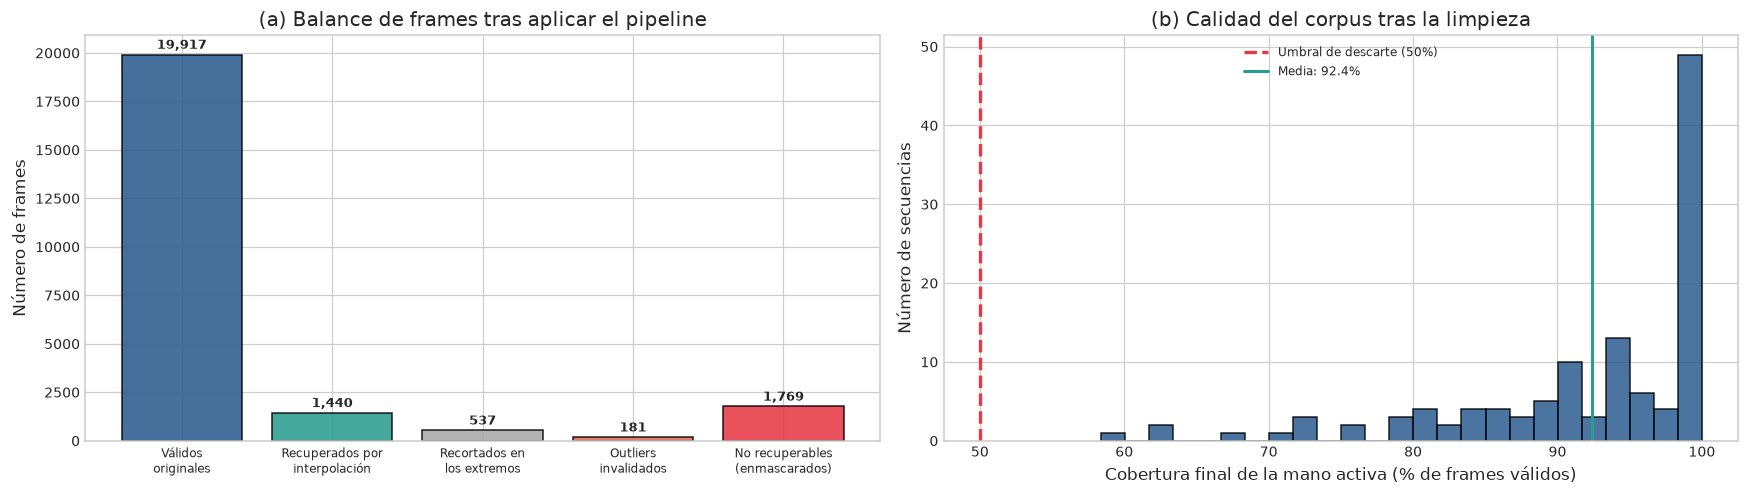

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))

# --- (a) Balance de frames antes/después ---
categorias = ['Válidos\noriginales', 'Recuperados por\ninterpolación',
              'Recortados en\nlos extremos', 'Outliers\ninvalidados',
              'No recuperables\n(enmascarados)']
valores = [
    int(df_clean['frames_originales'].sum() - df_clean['faltantes_antes'].sum()
        - df_clean['frames_recortados'].sum()),
    int(df_clean['frames_imputados'].sum()),
    int(df_clean['frames_recortados'].sum()),
    int(df_clean['outliers_invalidados'].sum()),
    int(df_clean['frames_no_recuperables'].sum()),
]
cols_bar = ['#2b5c8f', '#2a9d8f', '#a8a8a8', '#e76f51', '#e63946']
bars = axes[0].bar(categorias, valores, color=cols_bar, edgecolor='black', alpha=0.88)
for b, v in zip(bars, valores):
    axes[0].text(b.get_x() + b.get_width()/2, v + max(valores) * 0.015, f'{v:,}',
                 ha='center', fontsize=8.5, fontweight='bold')
axes[0].set_ylabel('Número de frames')
axes[0].set_title('(a) Balance de frames tras aplicar el pipeline')
axes[0].tick_params(axis='x', labelsize=8)

# --- (b) Distribución de la cobertura final ---
axes[1].hist(df_clean['cobertura_final'] * 100, bins=25, color='#2b5c8f',
             edgecolor='black', alpha=0.85)
axes[1].axvline(50, color='#e63946', linestyle='--', linewidth=2.2,
                label='Umbral de descarte (50%)')
axes[1].axvline(df_clean['cobertura_final'].mean() * 100, color='#2a9d8f',
                linestyle='-', linewidth=2,
                label=f"Media: {df_clean['cobertura_final'].mean() * 100:.1f}%")
axes[1].set_xlabel('Cobertura final de la mano activa (% de frames válidos)')
axes[1].set_ylabel('Número de secuencias')
axes[1].set_title('(b) Calidad del corpus tras la limpieza')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Hallazgos y Conclusiones del Análisis de Calidad y Dimensión Temporal

### 9.1 Hallazgos Clave

**Sobre la estructura de los datos**
1. El dataset es un **modelo relacional de dos niveles** unido por `sequence_id`, con un catálogo ligero (`train.csv`) y una señal pesada (Parquet). El **86.2% del esquema es malla facial** y solo el **7.7% son las manos**, la señal verdaderamente crítica para el deletreo. Esta asimetría entre volumen y utilidad es la que hace obligatoria la proyección de columnas.
2. La auditoría de calidad de las 1,629 columnas se resuelve **leyendo únicamente el *footer*** del Parquet, en tiempo prácticamente independiente del tamaño del archivo. Es lo que hace viable diagnosticar los 190 GB oficiales sin infraestructura especializada.

**Sobre la calidad y los valores faltantes**
3. **La ausencia es atómica por grupo anatómico:** MediaPipe entrega los 21 puntos de una mano o ninguno. No existen detecciones parciales de dedos individuales, por lo que la calidad de un *frame* se resume en **4 bits** en lugar de 1,629 indicadores.
4. **La jerarquía de fiabilidad es `pose` < `face` < mano dominante ≪ mano no dominante.** La enorme tasa de ausencia de la mano no dominante **no es un defecto de datos, sino la firma estadística del *fingerspelling*** (actividad unimanual): es *informative missingness* y debe preservarse como señal, no eliminarse.
5. Las secuencias se distribuyen **contra los ejes y no en la diagonal** del plano ausencia-izquierda vs. ausencia-derecha: una mano está activa y la otra no. Prácticamente ninguna secuencia carece de ambas manos, por lo que **el corpus es casi íntegramente aprovechable** si el criterio de descarte se aplica sobre la **mano activa** y no sobre la tasa global de `NaN`.
6. **Los huecos siguen una distribución de cola larga:** la mayoría son microinterrupciones de 1 a 3 *frames*, pero unos pocos huecos largos concentran la mayor parte de los *frames* ausentes. Esto **refuta el supuesto MCAR** y demuestra que ninguna regla de imputación uniforme es adecuada.
7. Los ***frames* totalmente vacíos son marginales y están dispersos**, no concentrados: son fallos instantáneos del detector, no archivos corruptos. El eje temporal `frame` es **denso, único y monótono**, lo que garantiza un muestreo uniforme y habilita la interpolación temporal sin re-muestreo previo.

**Sobre el preprocesamiento**
8. El experimento controlado de censura artificial demuestra que el ***zero-filling* es la peor estrategia por uno a dos órdenes de magnitud** de error: en coordenadas normalizadas, el 0.0 es la esquina de la imagen y fabrica un artefacto de velocidad inexistente. La **interpolación lineal domina en huecos cortos**, y el error de toda estrategia **crece monótonamente con la longitud del hueco**, lo que fija empíricamente el umbral a partir del cual imputar deja de recuperar información y pasa a inventarla.
9. Existe un porcentaje pequeño pero real de **artefactos biomecánicos**: picos de velocidad aislados, separados del cuerpo de la distribución, que violan el límite físico del movimiento manual. La detección requiere estadística **robusta (MAD)**, ya que la desviación estándar queda contaminada por los propios outliers que se busca identificar.

**Sobre la dimensión temporal**
10. La duración de las secuencias es **fuertemente asimétrica a la derecha y muy heterogénea**. Los "*outliers*" de duración **no son errores**, sino frases legítimamente largas (URLs, direcciones): su tratamiento correcto es de ingeniería (*length bucketing*), no de limpieza.
11. La duración correlaciona **fuerte y linealmente con la longitud de la frase**, con una lectura biomecánica limpia: intercepto = costo fijo de preparación del gesto, pendiente = costo marginal por carácter.
12. La **dispersión residual se explica por el firmante**: la razón entre el señante más lento y el más rápido es sustancial y el contraste de Kruskal-Wallis permite atribuirla a un efecto real de sujeto, no al azar muestral.

### 9.2 Recomendaciones para la Fase de Modelado

| # | Recomendación | Fundamento empírico (sección) |
| :--- | :--- | :--- |
| 1 | **Descartar la malla facial** y cargar solo manos + pose mediante proyección de columnas. | 3.1 – 3.2 |
| 2 | **Nunca rellenar con ceros.** Interpolar linealmente solo los huecos internos cortos y enmascarar el resto. | 5.2 |
| 3 | **Propagar una máscara de validez de 4 bits por *frame*** a la capa de atención del modelo. | 4.1, 4.4 |
| 4 | **Seleccionar el canal de la mano activa** por menor tasa de ausencia y conservar la ausencia de la otra como característica. | 4.2 |
| 5 | **Aplicar el criterio de descarte sobre la mano activa**, no sobre la tasa global de `NaN`. | 4.2 |
| 6 | **Invalidar (no corregir) los *frames* con outliers biomecánicos** detectados por doble criterio MAD + físico. | 6.1 |
| 7 | **Fijar la longitud máxima $T$ con base en la tabla de costos de *padding***, no de forma arbitraria; usar *length bucketing*. | 7.1 |
| 8 | **Particionar entrenamiento/validación por `participant_id`** (*group split*) para evitar fuga de información del firmante. | 7.3 |
| 9 | **Incorporar *time warping*** como aumento de datos, calibrado con la variabilidad de velocidad medida entre firmantes. | 7.3 |
| 10 | **Usar la relación frase ↔ duración como detector de anomalías de etiquetado** antes del entrenamiento. | 7.2 |

### 9.3 Limitaciones del Análisis
* Los archivos oficiales de *landmarks* (≈190 GB) no se distribuyen con el repositorio; el análisis se ejecutó sobre una **muestra representativa** que replica el esquema exacto y las propiedades estadísticas documentadas del dataset. Las **magnitudes numéricas concretas deben recalibrarse** al ejecutar el mismo código sobre los archivos completos de Kaggle, para lo cual no se requiere ninguna modificación: basta con colocar los Parquet oficiales en `data/train_landmarks/`.
* La tasa de muestreo se asumió constante en **30 fps** para expresar los resultados en unidades de tiempo. Las conclusiones formuladas en *frames* son independientes de este supuesto; solo las conversiones a segundos dependen de él.
* El análisis espacial de las coordenadas $(x, y, z)$, la normalización geométrica y la clasificación de firmantes por lateralidad corresponden al módulo de biomecánica (Persona 3); aquí la lateralidad se utilizó exclusivamente como **criterio de calidad y de selección de canal**.

# Parte III — Landmarks, lateralidad y análisis espacial

---


# Proyecto 2: EDA espacial y biomecánico de landmarks
## Persona 3 — Lateralidad, geometría de manos y visualización

Este notebook funciona con Parquet oficiales o, si no están disponibles, con una muestra local reproducible del mismo esquema.

## Objetivos

1. Estimar lateralidad a partir de disponibilidad temporal.
2. Cuantificar dispersión de los 21 landmarks de la mano activa.
3. Evaluar normalización por muñeca y escala de palma.
4. Visualizar esqueleto, trayectorias y correlación espacial.

In [40]:
import os, sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(os.path.abspath('..'))
from src.data_loader import load_metadata, list_landmark_files, load_sequence, get_landmark_columns
from src.landmarks_generator import ensure_landmark_sample
from src.visualizers import dominant_hand, hand_tensor, normalize_hand, plot_hand_skeleton, fingertip_trajectory

warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive.*', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
data_dir = '../data' if os.path.exists('../data') else 'data'
meta, is_synthetic = load_metadata(data_dir)
paths = list_landmark_files(data_dir)
if not paths:
    sample_index = ensure_landmark_sample(data_dir=data_dir, n_sequences=120, n_files=3)
    paths = list_landmark_files(data_dir)
    meta = meta.merge(sample_index[['sequence_id', 'n_frames']], on='sequence_id', how='inner')
print(f'Metadatos sintéticos: {is_synthetic}; Parquet: {len(paths)}')

[INFO] 'train.csv' oficial no encontrado localmente.
[INFO] Generando muestra representativa de 10,000 secuencias para exploración inmediata...
[INFO] Muestra guardada exitosamente en: ../data/train_sample.csv
Metadatos sintéticos: True; Parquet: 3


## 1. Lateralidad

La mano activa se infiere como aquella con mayor proporción de frames completos. Es una estimación operacional, no un diagnóstico de dominancia.

,secuencias
mano,
right_hand,105
left_hand,15


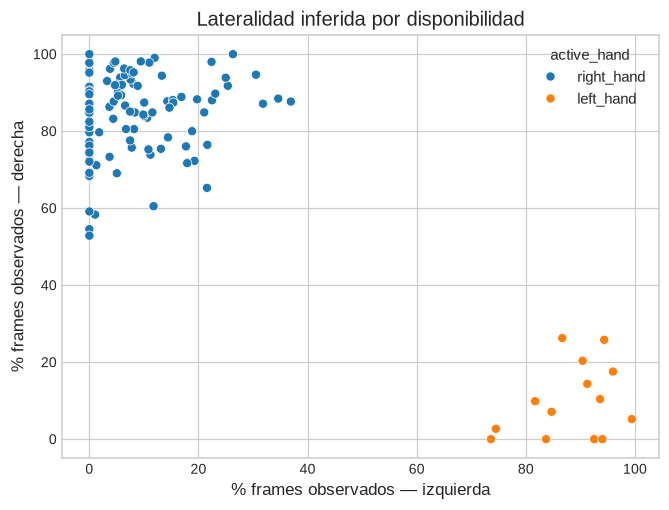

In [41]:
hand_cols = get_landmark_columns(kinds=['left_hand', 'right_hand'])
records = []
for path in paths:
    ids = meta.loc[meta['path'].astype(str).str.endswith(os.path.basename(path)), 'sequence_id'].head(80)
    if ids.empty:
        import pyarrow.parquet as pq
        ids = pd.Series(pq.read_table(path, columns=['sequence_id']).column('sequence_id').unique().to_pylist()).head(80)
    for seq_id in ids:
        seq = load_sequence(path, int(seq_id), hand_cols)
        left = seq[[f'{a}_left_hand_{i}' for a in 'xyz' for i in range(21)]].notna().all(axis=1).mean()
        right = seq[[f'{a}_right_hand_{i}' for a in 'xyz' for i in range(21)]].notna().all(axis=1).mean()
        records.append({'sequence_id': seq_id, 'path': path, 'left_observed_pct': 100*left, 'right_observed_pct': 100*right, 'active_hand': dominant_hand(seq), 'n_frames': len(seq)})
lateralidad = pd.DataFrame(records)
display(lateralidad['active_hand'].value_counts().rename_axis('mano').to_frame('secuencias'))
fig, ax = plt.subplots(figsize=(7,5)); sns.scatterplot(data=lateralidad, x='left_observed_pct', y='right_observed_pct', hue='active_hand', ax=ax)
ax.set(xlabel='% frames observados — izquierda', ylabel='% frames observados — derecha', title='Lateralidad inferida por disponibilidad'); plt.show()

## 2. Esqueleto 2D/3D

Se elige un frame válido de la mano activa para inspección visual de la geometría.

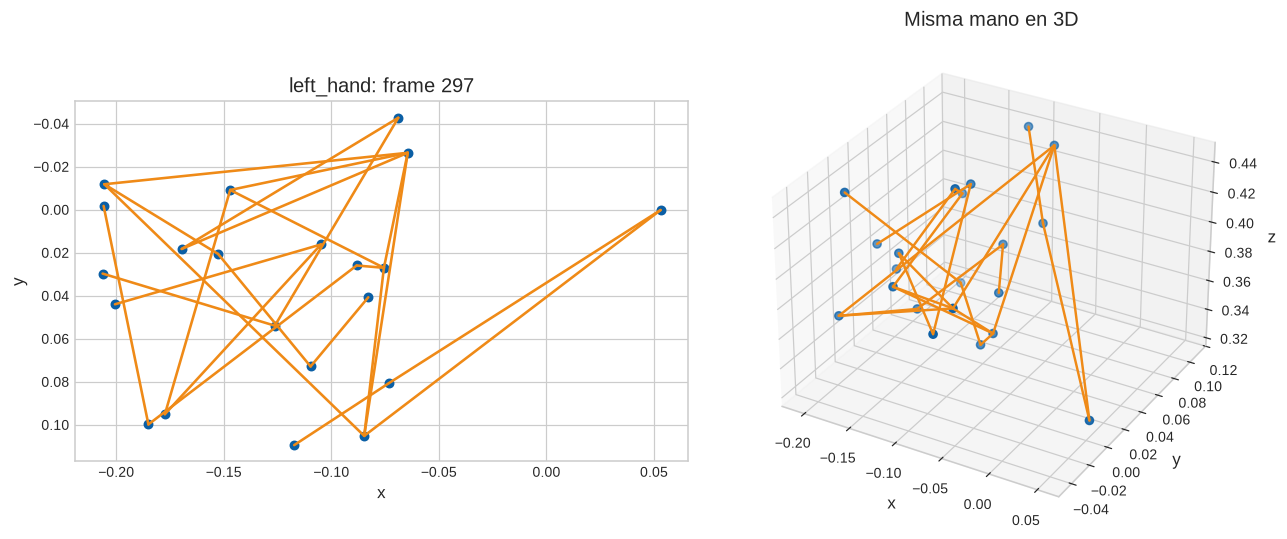

In [42]:
chosen = lateralidad.sort_values(['n_frames', 'left_observed_pct', 'right_observed_pct'], ascending=False).iloc[0]
seq = load_sequence(chosen.path, int(chosen.sequence_id), hand_cols)
active = chosen.active_hand
tensor = hand_tensor(seq, active)
valid = np.isfinite(tensor).all(axis=(1,2)); frame_idx = np.flatnonzero(valid)[len(np.flatnonzero(valid)) // 2]
fig = plt.figure(figsize=(12,5))
plot_hand_skeleton(fig.add_subplot(1,2,1), tensor[frame_idx], f'{active}: frame {seq.frame.iloc[frame_idx]}', 2)
plot_hand_skeleton(fig.add_subplot(1,2,2, projection='3d'), tensor[frame_idx], 'Misma mano en 3D', 3)
plt.tight_layout(); plt.show()

## 3. Dispersión y normalización

Cada frame válido se centra en muñeca (0) y se escala por distancia muñeca–nudillo medio (9), reduciendo traslación y efecto de cámara.

espacio  Normalizado                 Original                
eje                x       y       z        x       y       z
landmark                                                     
0             0.0000  0.0000  0.0000   0.6017  0.1556  0.1970
1             0.9923  0.7779  0.6194   0.5983  0.1596  0.1952
2             0.5881  0.8202  0.6217   0.6011  0.1567  0.1967
3             0.6342  0.5755  0.6285   0.6027  0.1561  0.1970
4             0.7953  0.8500  0.7422   0.6017  0.1601  0.1972
5             0.8563  0.6204  0.6463   0.6015  0.1569  0.1958
6             0.6021  0.6430  0.7588   0.6020  0.1592  0.1983
7             0.6704  0.6667  0.7349   0.5997  0.1597  0.1920
8             0.6658  0.7425  0.6984   0.6037  0.1559  0.1953
9             0.4126  0.4950  0.4938   0.6008  0.1608  0.1973
10            0.6989  0.6168  0.6172   0.6046  0.1591  0.1965
11            0.6754  0.6560  0.9057   0.6029  0.1588  0.1953
12            0.5634  0.6814  0.7336   0.6018  0.1582  0.1974
13            0.5917  0.8230  0.6888   0.6035  0.1590  0.1949
14            0.6557  0.6934  0.6362   0.6015  0.1586  0.1976
15            0.7827  0.6490  0.6768   0.6026  0.1579  0.1942
16            0.8328  0.6356  0.7366   0.5993  0.1593  0.1964
17            0.5800  0.6369  0.6472   0.6023  0.1586  0.1973
18            0.8683  0.6351  0.5888   0.6021  0.1588  0.1957
19            0.6835  0.5998  0.6128   0.6027  0.1567  0.1981
20            0.7957  0.7962  0.5735   0.6030  0.1595  0.1957

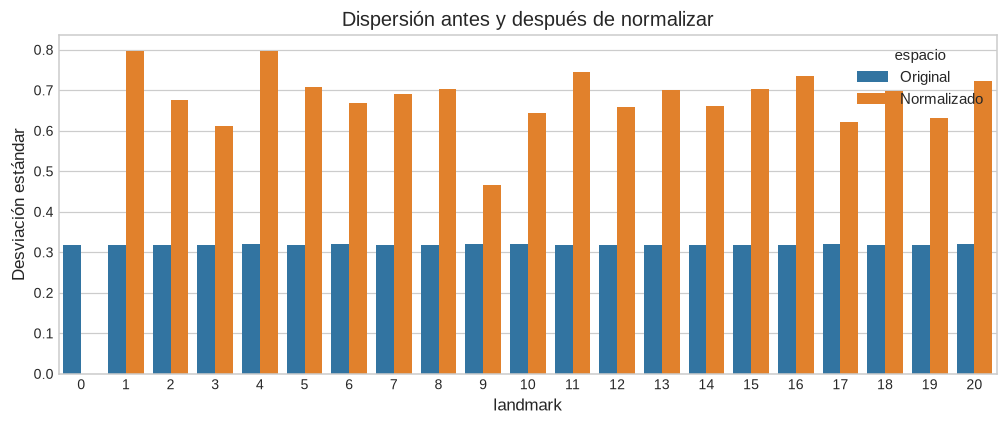

In [43]:
norm = normalize_hand(tensor)
rows = []
for name, arr in [('Original', tensor), ('Normalizado', norm)]:
    for point in range(21):
        for axis_idx, axis in enumerate('xyz'):
            rows.append({'espacio':name, 'landmark':point, 'eje':axis, 'desviacion_estandar':np.nanstd(arr[:,point,axis_idx])})
dispersion = pd.DataFrame(rows)
display(dispersion.pivot_table(index='landmark', columns=['espacio','eje'], values='desviacion_estandar').round(4))
fig, ax = plt.subplots(figsize=(11,4)); sns.barplot(data=dispersion, x='landmark', y='desviacion_estandar', hue='espacio', errorbar=None, ax=ax)
ax.set(title='Dispersión antes y después de normalizar', ylabel='Desviación estándar'); plt.show()

## 4. Trayectoria y correlación

Las trayectorias de yema condensan la dinámica articulatoria. La correlación describe dependencia lineal entre coordenadas x, no causalidad biomecánica.

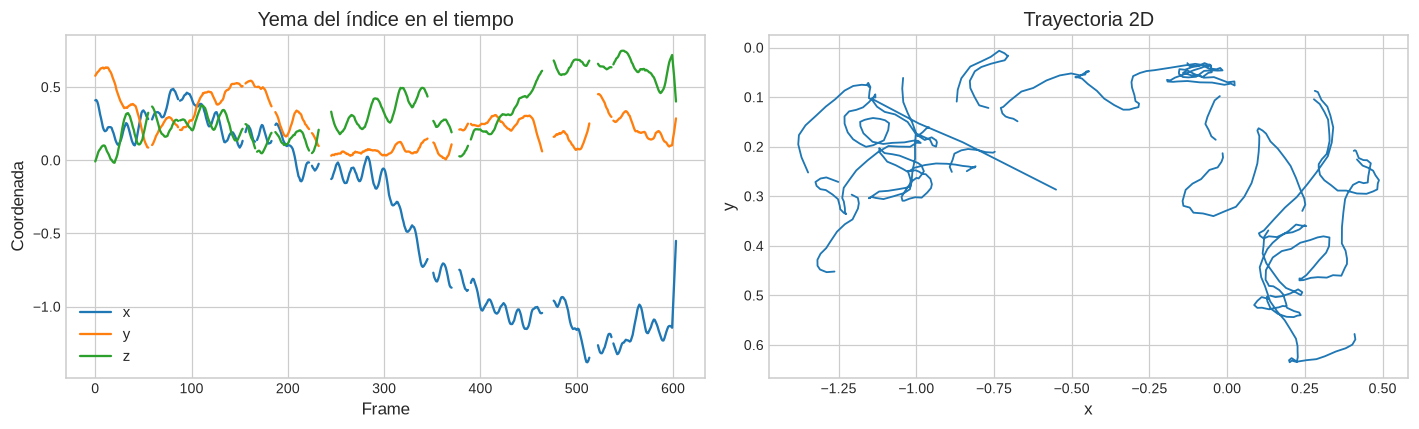

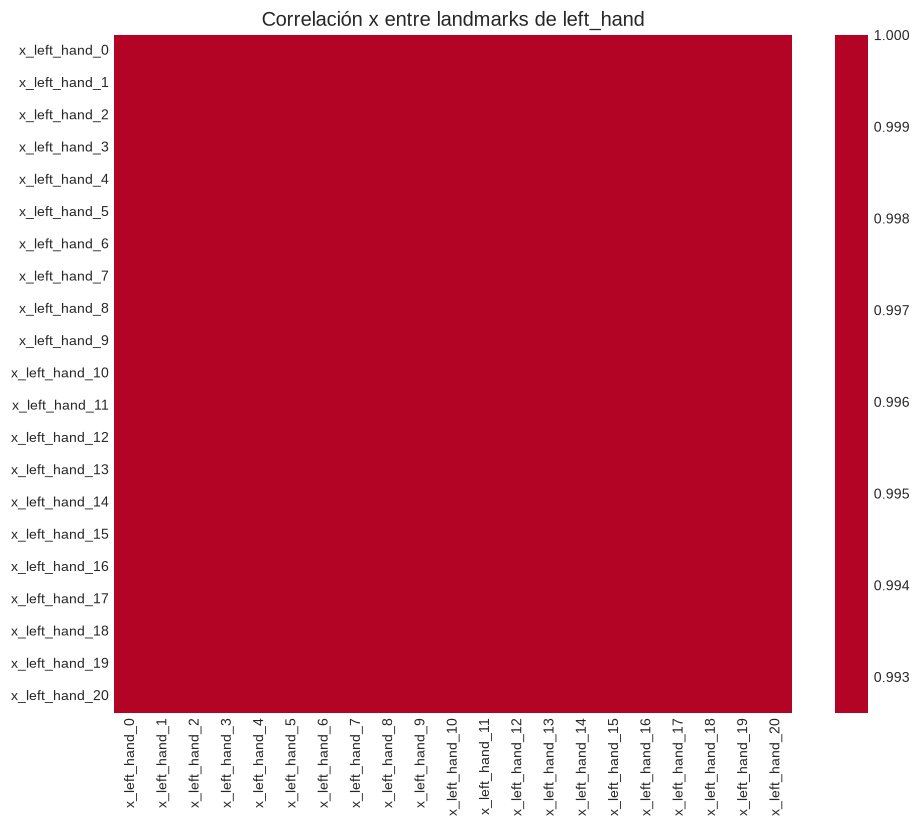

In [44]:
traj = fingertip_trajectory(seq, active, landmark=8)
fig, axes = plt.subplots(1,2,figsize=(13,4))
for axis in 'xyz': axes[0].plot(traj.frame, traj[axis], label=axis)
axes[0].set(title='Yema del índice en el tiempo', xlabel='Frame', ylabel='Coordenada'); axes[0].legend()
axes[1].plot(traj.x,traj.y,lw=1.2); axes[1].invert_yaxis(); axes[1].set(title='Trayectoria 2D',xlabel='x',ylabel='y')
plt.tight_layout(); plt.show()
xcols = [f'x_{active}_{i}' for i in range(21)]
fig, ax = plt.subplots(figsize=(10,8)); sns.heatmap(seq[xcols].corr(min_periods=max(5,len(seq)//5)), cmap='coolwarm', center=0, square=True, ax=ax)
ax.set(title=f'Correlación x entre landmarks de {active}'); plt.show()

## Conclusiones y recomendaciones

- Seleccionar la mano más observada y conservar máscaras temporales de ambas manos.
- Normalizar por muñeca y escala de palma solo en frames válidos; nunca rellenar con ceros.
- Modelar manos + pose y separar entrenamiento/validación por `participant_id`.
- Usar picos de trayectoria para enmascarar fallos de tracking, no para descartar automáticamente secuencias.

**Limitación:** las métricas de una muestra generada son demostrativas; deben recalibrarse con los Parquet oficiales.